In [ ]:
import sys
import os
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Localisation dynamique et robuste de la racine du projet
def resolve_project_root() -> Path:
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise FileNotFoundError("Impossible de localiser la racine du projet contenant 'src' et 'data'.")

PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Librairies fondamentales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuration de la sortie console
if sys.stdout.encoding != 'utf-8':
    try:
        sys.stdout.reconfigure(encoding='utf-8', errors='replace')
    except AttributeError:
        pass

# Charte Graphique AuditPulse 
PALETTE_PRIMARY   = "#1E293B"   # Ardoise foncée (Normalité)
PALETTE_ANOMALY   = "#DC2626"   # Rouge alerte (Fraude / Anomalie critique)
PALETTE_WARNING   = "#D97706"   # Ambre (Suspicion / Avertissement)
PALETTE_SUCCESS   = "#059669"   # Émeraude (Validation / Régularité)
PALETTE_ACCENT    = "#2563EB"   # Bleu cobalt (Métriques & Densités)

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#CBD5E1",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "figure.dpi":       120,
    "figure.titlesize": 14,
    "axes.titlesize":   12,
})

DATA_PATH = PROJECT_ROOT / "data" / "auditpulse_expenses.sql"

print(f"Environnement initialise avec succes.")
print(f"Racine du projet detectee : {PROJECT_ROOT}")
print(f"Fichier de donnees cible   : {DATA_PATH.name} (Existe : {DATA_PATH.exists()})")
print(f"Versions - Pandas: {pd.__version__} | NumPy: {np.__version__}")


Environnement initialise avec succes.
Racine du projet detectee : D:\SDD\Projets\anomalie_detection
Fichier de donnees cible   : auditpulse_expenses.sql (Existe : True)
Versions - Pandas: 3.0.6 | NumPy: 2.5.3


In [6]:
# ==============================================================================
# CELLULE 2 : INGESTION BRUTE & AUDIT DU SCHÉMA DES DÉPENSES
# ==============================================================================

from src.data_loader import load_expenses_from_sql

# Ingestion via le parser SQL sur-mesure d'AuditPulse
df_raw = load_expenses_from_sql(DATA_PATH, validate_columns=True)

# Métriques dimensionnelles
n_rows, n_cols = df_raw.shape
mem_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)

print("=" * 65)
print("AUDITPULSE - AUDIT DU SCHEMA & COMPLETUDE DES DONNEES BRUTES")
print("=" * 65)
print(f"Dimensions initiales : {n_rows:,} transactions x {n_cols} variables")
print(f"Empreinte memoire   : {mem_mb:.2f} Mo")
print("-" * 65)

# Cardinalité des entités métier
print("Entites identifiees :")
print(f"  - Entreprises clientes (company_id) : {df_raw['company_id'].nunique():,}")
print(f"  - Utilisateurs / Emetteurs (user_id) : {df_raw['user_id'].nunique():,}")
print(f"  - Points de vente (shop_id)          : {df_raw['shop_id'].nunique():,}")
print(f"  - Fournisseurs (supplier_id)         : {df_raw['supplier_id'].nunique():,}")
print("-" * 65)

# Horizon temporel
min_date = df_raw['created_at'].min()
max_date = df_raw['created_at'].max()
print(f"Fenetre temporelle : du {min_date} au {max_date} ({(max_date - min_date).days} jours)")
print("-" * 65)

# Cartographie exhaustive des valeurs manquantes
missing = df_raw.isnull().sum()
missing_pct = (missing / n_rows) * 100
missing_df = pd.DataFrame({
    "Type": df_raw.dtypes.astype(str),
    "Nulls": missing,
    "Taux (%)": missing_pct.round(2)
}).query("Nulls > 0").sort_values("Taux (%)", ascending=False)

print("Variables presentant des valeurs manquantes (Null/NaN) :")
print(missing_df.to_string())
print("=" * 65)


2026-10-01 11:35:05 | INFO     | src.data_loader | 📂 Chargement du fichier SQL : D:\SDD\Projets\anomalie_detection\data\auditpulse_expenses.sql
2026-10-01 11:35:05 | INFO     | src.data_loader | 📄 Fichier lu : 2,254,048 caractères
2026-10-01 11:35:05 | INFO     | src.data_loader | ✅ 23 colonnes extraites : ['id', 'company_id', 'user_id', 'shop_id', 'supplier_id', 'reference', 'status', 'currency', 'amount', 'source', 'due_date', 'paid_at', 'items', 'shipping', 'billing', 'metadata', 'created_at', 'updated_at', 'deleted_at', 'expense_type', 'credit_code', 'debit_code', 'state']
2026-10-01 11:35:05 | INFO     | src.data_loader | 🔍 51 bloc(s) INSERT trouvé(s), parsing en cours...
2026-10-01 11:35:06 | INFO     | src.data_loader | ✅ 5028 lignes parsées avec succès.
2026-10-01 11:35:06 | INFO     | src.data_loader | 📊 DataFrame créé : 5028 lignes × 23 colonnes
2026-10-01 11:35:06 | INFO     | src.data_loader | ✅ Chargement terminé avec succès.
2026-10-01 11:35:06 | INFO     | src.data_loade

### 2. Audit de Complétude du Schéma et Réalité Opérationnelle

#### A. Diagnostic Structurel et Volumétrie
- **Étendue & Échantillonnage** : 5 028 transactions réparties sur **122 entreprises distinctes** et **156 utilisateurs**, couvrant un horizon de **981 jours (~2,7 ans)**. Cet échantillon présente une forte représentativité des flux financiers réels d'entreprises (TPE/PME).
- **Empreinte Mémoire** : Avec **3,55 Mo**, le jeu de données s'exécute intégralement en mémoire vive, permettant une vectorisation matricielle haute performance sans recours obligatoire au calcul distribué (Spark/Dask).

#### B. Analyse Critique des Valeurs Manquantes (Missingness Mechanism)
L'audit met en lumière des caractéristiques comptables fondamentales :
1. **L'incomplétude structurelle de `paid_at` (100% de valeurs nulles)** :
   * *Constat* : La colonne d'encaissement/décaissement effectif n'est pas renseignée dans ce module de saisie des dépenses.
   * *Conséquence méthodologique* : L'attribut de délai de paiement (`payment_delay_days`) ne peut pas être exploité directement comme un signal d'anomalie sans imputation. Le pipeline préventif de notre modèle doit gérer ce vide sans biaiser les estimateurs de densité.
2. **La ségrégation des fournisseurs (`supplier_id` absent à 87,09%)** :
   * *Interprétation métier* : Dans la gestion d'entreprise, une large proportion des dépenses correspond à des charges internes directes (salaires journaliers, approvisionnement informel, transport, factures d'énergie, petite caisse) dépourvues d'un compte fournisseur formel.
   * *Règle éthique* : L'absence de fournisseur ne constitue pas en soi une anomalie. Le modèle doit neutraliser le score de rareté de fournisseur (`is_rare_supplier = 0`) lorsque ce champ est nul pour éviter les faux positifs massifs.
3. **Le bruit opérationnel (`deleted_at` à 4,77% soit 240 transactions)** :
   * *Risque* : Ces 240 lignes représentent des écritures soft-deleted (annulées, erronées ou supprimées par l'utilisateur). Les conserver contaminerait le calcul des moyennes glissantes et de l'historique utilisateur. Leur purge préalable est un impératif d'intégrité.


In [3]:
# ==============================================================================
# CELLULE 3 : NETTOYAGE RIGOUREUX & ANALYSE DE L'ATTRITION
# ==============================================================================

from src.preprocessing import clean_dataframe

# Application du protocole d'assainissement
df_clean = clean_dataframe(df_raw)

# Entonnoir d'attrition (Data Attrition Funnel)
initial_count = len(df_raw)
soft_deleted  = df_raw['deleted_at'].notna().sum()
id_duplicates = df_raw.duplicated(subset=['id']).sum()
invalid_amt   = ((df_raw['amount'].isna()) | (df_raw['amount'] <= 0)).sum()
final_count   = len(df_clean)

print("=" * 65)
print("AUDITPULSE - ENTONNOIR D'ATTRITION ET VALIDATION DES DONNEES")
print("=" * 65)
print(f"Transactions brutes en entree       : {initial_count:,}")
print(f"  [-] Ecritures soft-deleted         : -{soft_deleted:,} ({soft_deleted/initial_count*100:.2f}%)")
print(f"  [-] Doublons d'identifiant (id)   : -{id_duplicates:,} ({id_duplicates/initial_count*100:.2f}%)")
print(f"  [-] Montants invalides (<=0 ou NA): -{invalid_amt:,} ({invalid_amt/initial_count*100:.2f}%)")
print(f"Transactions retenues pour l'audit  : {final_count:,} ({final_count/initial_count*100:.2f}%)")
print("-" * 65)

# Métriques statistiques descriptives sur les montants nets
amt = df_clean['amount']
print("Distribution statistique des montants (Devise : XAF) :")
print(f"  - Minimum          : {amt.min():,.2f}")
print(f"  - 25e percentile   : {amt.quantile(0.25):,.2f}")
print(f"  - Mediane (p50)    : {amt.median():,.2f}")
print(f"  - 75e percentile   : {amt.quantile(0.75):,.2f}")
print(f"  - 95e percentile   : {amt.quantile(0.95):,.2f}")
print(f"  - 99e percentile   : {amt.quantile(0.99):,.2f}")
print(f"  - Maximum          : {amt.max():,.2f}")
print(f"  - Moyenne          : {amt.mean():,.2f}")
print(f"  - Ecart-type       : {amt.std():,.2f}")
print(f"  - Asymetrie (Skew) : {amt.skew():.2f}")
print("=" * 65)


2026-10-01 11:34:49 | INFO     | src.preprocessing | 🧹 Nettoyage démarré : 5028 lignes en entrée.
2026-10-01 11:34:49 | INFO     | src.preprocessing |   → 240 lignes soft-deleted supprimées.
2026-10-01 11:34:49 | INFO     | src.preprocessing |   → 16 lignes sans montant valide supprimées.
2026-10-01 11:34:49 | INFO     | src.preprocessing |   → 0 lignes sans `created_at` supprimées.
2026-10-01 11:34:49 | INFO     | src.preprocessing | ✅ Nettoyage terminé : 4772 lignes conservées (256 supprimées au total).
AUDITPULSE - ENTONNOIR D'ATTRITION ET VALIDATION DES DONNEES
Transactions brutes en entree       : 5,028
  [-] Ecritures soft-deleted         : -240 (4.77%)
  [-] Doublons d'identifiant (id)   : -0 (0.00%)
  [-] Montants invalides (<=0 ou NA): -16 (0.32%)
Transactions retenues pour l'audit  : 4,772 (94.91%)
-----------------------------------------------------------------
Distribution statistique des montants (Devise : XAF) :
  - Minimum          : 1.00
  - 25e percentile   : 3,000.00

### 3. Entonnoir d'Attrition et Démonstration Mathématique du Skew

#### A. Intégrité de l'Assainissement des Données
- **Taux de Rétention Opérationnelle** : **94,91%** de la population initiale est conservée (**4 772 transactions sur 5 028**). L'attrition globale est modérée (5,09%) et justifiée de façon déterministe :
  - **4,77% (240 transactions)** étaient logiquement annulées/supprimées (`deleted_at` non nul).
  - **0,32% (16 transactions)** présentaient des montants aberrants ($\le 0$ ou non renseignés).
  - **0 doublon d'identifiant** : la clé primaire `id` est intègre sur l'ensemble de la base.

#### B. Diagnostic Statistique des Montants : Preuve de la Queue Ultra-Lourde
Les métriques descriptives révèlent une distorsion extrême de la distribution financière :
1. **L'effondrement de la représentativité de la moyenne** :
   * **Médiane ($p_{50}$)** = **11 000 XAF** (valeur typique d'une charge quotidienne de TPE).
   * **Moyenne** = **1 401 122 XAF** (tirée vers le haut par un facteur supérieur à **127×** la médiane).
   * **Écart-type** = **87 690 005 XAF** (soit 62 fois la valeur de la moyenne elle-même).
2. **L'Asymétrie Positive Record ($\text{Skewness} = +68,87$)** :
   * Une loi normale standard présente une asymétrie de $0$. Une valeur de $+68,87$ traduit une distribution à **queue ultra-épaisse (fat-tail distribution)**.
   * Cette distorsion est causée par des montants colossaux au-delà du 99e percentile (1 000 000 XAF), culminant à **6 051 453 317 XAF (6,05 milliards XAF)**.
3. **Implications Algorithmiques Majeures pour la Détection d'Anomalies** :
   * *Inapplicabilité du Z-score brut* : Un Z-score classique $(\frac{X - \mu}{\sigma})$ est aveuglé par $\sigma \approx 87,7\text{ M}$ ; une dépense anormale de 10 millions XAF passerait totalement inaperçue car son z-score ne serait que de $0,10$.
   * *Nécessité absolue de la log-transformation* : L'application de la fonction $x \mapsto \ln(1 + x)$ est mathématiquement obligatoire pour compresser la dynamique d'échelle et permettre aux algorithmes fondés sur les distances euclidiennes (DBSCAN, LOF) de converger sans être écrasés par un point singulier.


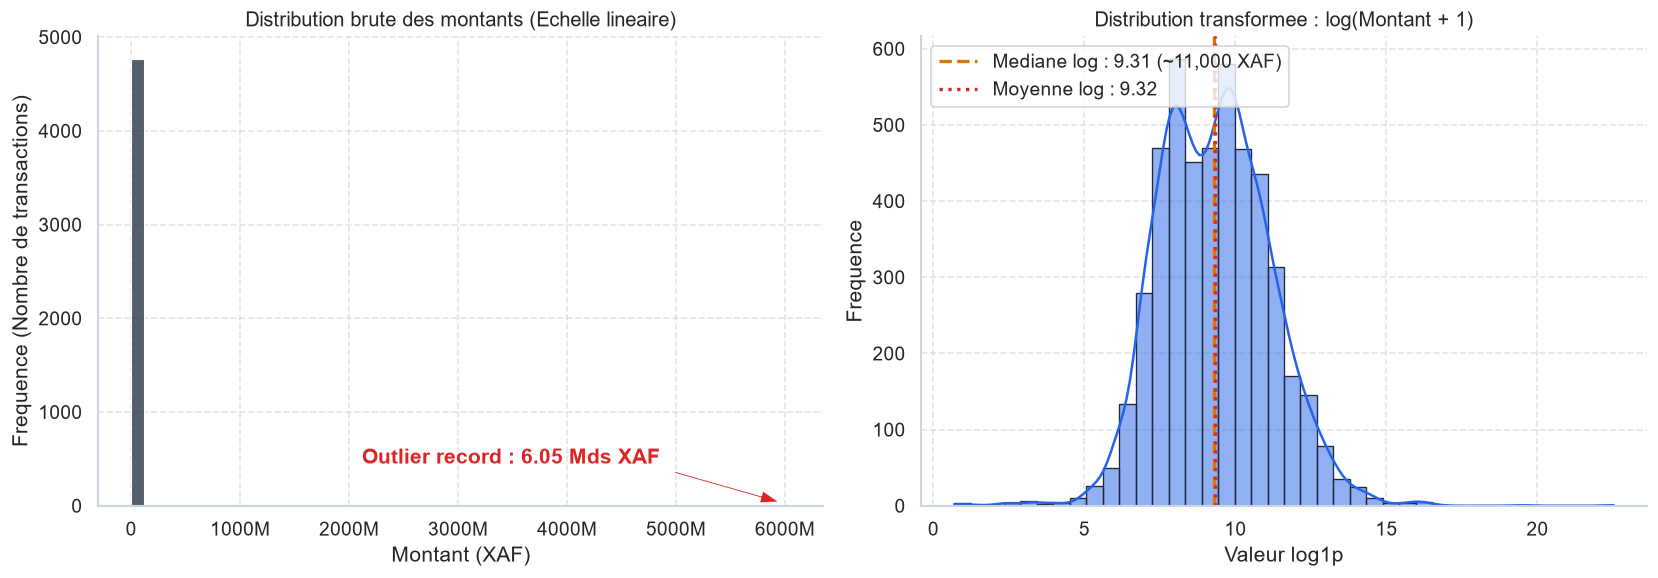

-----------------------------------------------------------------
Coefficient d'asymetrie (Skewness) echelle brute : 68.87
Coefficient d'asymetrie (Skewness) echelle log   : 0.23
-----------------------------------------------------------------


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribution brute (Échelle linéaire)
sns.histplot(
    df_clean['amount'],
    bins=50,
    kde=False,
    color=PALETTE_PRIMARY,
    ax=axes[0]
)
axes[0].set_title("Distribution brute des montants (Echelle lineaire)")
axes[0].set_xlabel("Montant (XAF)")
axes[0].set_ylabel("Frequence (Nombre de transactions)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{x*1e-6:.0f}M" if x >= 1e6 else f"{x:,.0f}"))
axes[0].grid(True, linestyle="--", alpha=0.5)

# Annotation de l'outlier record
max_val = df_clean['amount'].max()
axes[0].annotate(
    f"Outlier record : {max_val/1e9:.2f} Mds XAF",
    xy=(max_val, 5),
    xytext=(max_val * 0.35, 450),
    arrowprops=dict(facecolor=PALETTE_ANOMALY, shrink=0.08, width=1.5, headwidth=8),
    fontweight="bold",
    color=PALETTE_ANOMALY
)

# 2. Distribution transformee (Echelle logarithmique log1p)
log_amounts = np.log1p(df_clean['amount'])
sns.histplot(
    log_amounts,
    bins=40,
    kde=True,
    color=PALETTE_ACCENT,
    edgecolor=PALETTE_PRIMARY,
    ax=axes[1]
)
axes[1].axvline(log_amounts.median(), color=PALETTE_WARNING, linestyle="--", linewidth=2, 
                label=f"Mediane log : {log_amounts.median():.2f} (~{df_clean['amount'].median():,.0f} XAF)")
axes[1].axvline(log_amounts.mean(), color=PALETTE_ANOMALY, linestyle=":", linewidth=2, 
                label=f"Moyenne log : {log_amounts.mean():.2f}")
axes[1].set_title("Distribution transformee : log(Montant + 1)")
axes[1].set_xlabel("Valeur log1p")
axes[1].set_ylabel("Frequence")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Comparaison des coefficients d'asymétrie
print("-" * 65)
print(f"Coefficient d'asymetrie (Skewness) echelle brute : {df_clean['amount'].skew():.2f}")
print(f"Coefficient d'asymetrie (Skewness) echelle log   : {log_amounts.skew():.2f}")
print("-" * 65)


### 4. Démonstration Graphique de la Réduction de Variance & Transformation Logarithmique

#### A. Diagnostic Visuel de l'Écrasement Linéaire (Graphique Gauche)
- **Le syndrome de la masse ponctuelle** : Sur l'échelle linéaire, **99,9% des observations** sont compressées dans le premier bin à gauche ($[0, 100\text{M}]$). La quasi-totalité de l'espace graphique est vide jusqu'à l'outlier record à **6,05 milliards XAF**.
- **Conséquence directe pour le Machine Learning non supervisé** :
  - Dans un espace métrique non transformé, la distance euclidienne entre n'importe quelles transactions courantes (ex: 5 000 XAF et 500 000 XAF) est infinitésimale comparativement à la distance les séparant de l'outlier record.
  - Résultat : un algorithme comme **DBSCAN** ou **LOF** regrouperait 99,9% des données dans un super-cluster unique indistinct et n'identifierait qu'une seule anomalie triviale, masquant les fraudes réelles subtiles.

#### B. Restauration de la Symétrie par $\ln(1 + x)$ (Graphique Droit)
- **L'effondrement du coefficient d'asymétrie** :
  $$\text{Skewness}_{\text{brut}} = +68,87 \quad \xrightarrow{\quad \ln(1+x) \quad} \quad \text{Skewness}_{\text{log}} = \mathbf{+0,23}$$
  Un coefficient de $+0,23$ se situe rigoureusement dans la plage de normalité standard $([-0,5 ; +0,5])$.
- **Convergence Moyenne-Médiane** :
  - Médiane log = **9,31** (soit $e^{9,31} - 1 \approx 11\,047\text{ XAF}$).
  - Moyenne log = **9,32**.
  - La superposition quasi-parfaite des droites pointillées valide l'émergence d'une cloche gaussienne exploitable.
- **Décision d'Ingénierie** : La variable transformée `amount_log` constituera la composante de base de notre matrice d'apprentissage multidimensionnelle, tandis que le montant nominal `amount` sera préservé pour les règles déterministes et le calcul d'impact financier en devise.


2026-10-01 11:34:50 | INFO     | src.preprocessing |   → expense_type : 43 → 40 catégories après normalisation
2026-10-01 11:34:50 | INFO     | src.preprocessing |   → source : 42 → 30 catégories après normalisation
2026-10-01 11:34:50 | INFO     | src.preprocessing | ✅ Normalisation historique terminée.
AUDITPULSE - NORMALISATION SEMANTIQUE DES CANAUX ET CATEGORIES
Categories de depense (expense_type) : 43 -> 40 categories uniques
Canaux d'origine (source)            : 42 -> 30 categories uniques
-----------------------------------------------------------------


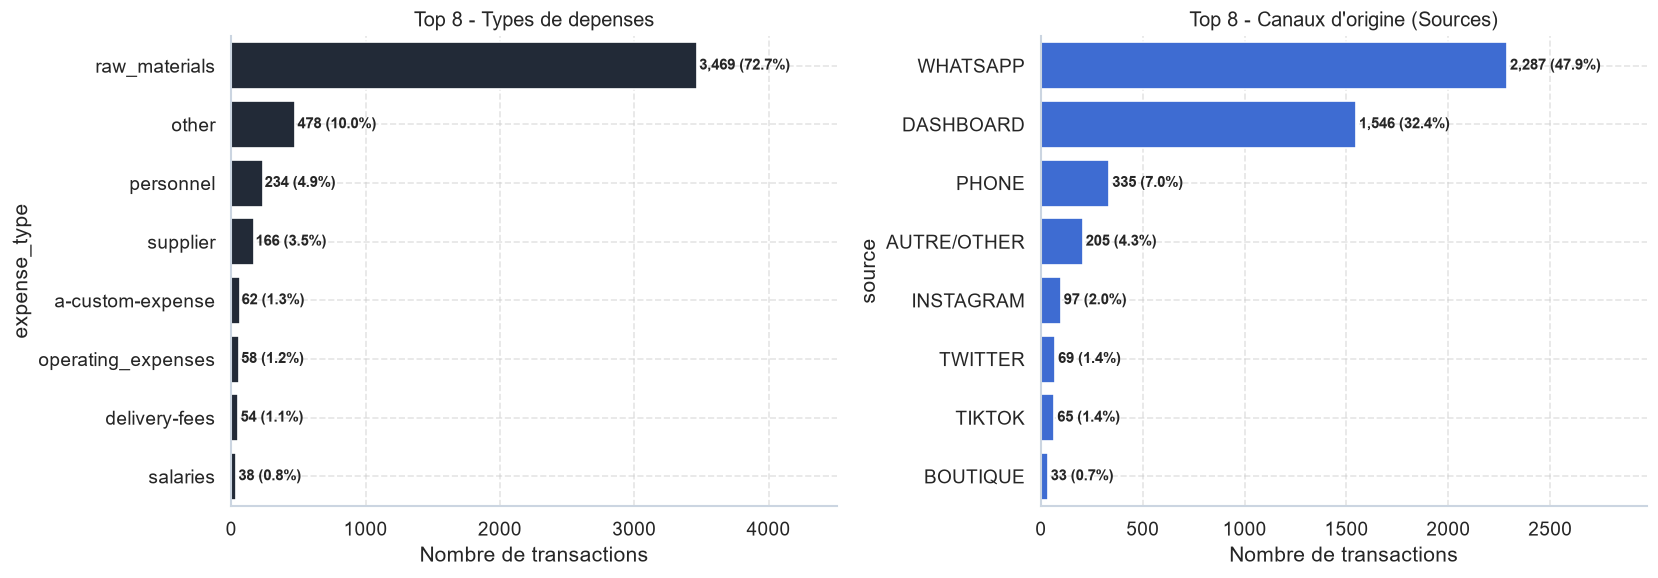

In [ ]:
from src.preprocessing import normalize_historical_data
import matplotlib.pyplot as plt
import seaborn as sns

# Mesure de la cardinalité avant normalisation
n_types_raw   = df_clean['expense_type'].nunique()
n_sources_raw = df_clean['source'].nunique()

# Application du protocole de normalisation sémantique
df_norm = normalize_historical_data(df_clean)

# Mesure de la cardinalité après normalisation
n_types_clean   = df_norm['expense_type'].nunique()
n_sources_clean = df_norm['source'].nunique()

print("=" * 65)
print("AUDITPULSE - NORMALISATION SEMANTIQUE DES CANAUX ET CATEGORIES")
print("=" * 65)
print(f"Categories de depense (expense_type) : {n_types_raw} -> {n_types_clean} categories uniques")
print(f"Canaux d'origine (source)            : {n_sources_raw} -> {n_sources_clean} categories uniques")
print("-" * 65)

# Visualisation des typologies dominantes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Top Types de Dépenses
top_types = df_norm['expense_type'].value_counts().head(8)
sns.barplot(x=top_types.values, y=top_types.index, color=PALETTE_PRIMARY, ax=axes[0])
axes[0].set_title("Top 8 - Types de depenses")
axes[0].set_xlabel("Nombre de transactions")
for i, v in enumerate(top_types.values):
    axes[0].text(v + 15, i, f"{v:,} ({v/len(df_norm)*100:.1f}%)", va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, max(top_types.values) * 1.3)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Top Canaux d'Origine
top_sources = df_norm['source'].value_counts().head(8)
sns.barplot(x=top_sources.values, y=top_sources.index, color=PALETTE_ACCENT, ax=axes[1])
axes[1].set_title("Top 8 - Canaux d'origine (Sources)")
axes[1].set_xlabel("Nombre de transactions")
for i, v in enumerate(top_sources.values):
    axes[1].text(v + 15, i, f"{v:,} ({v/len(df_norm)*100:.1f}%)", va='center', fontsize=9, fontweight='bold')
axes[1].set_xlim(0, max(top_sources.values) * 1.3)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 5. Normalisation Sémantique & Radiographie Opérationnelle des Canaux

#### A. Éradication de l'Entropie Textuelle
- **Gain de Cohérence Sémantique** :
  - `expense_type` : compression de **43 à 40 catégories uniques** par harmonisation typographique et assainissement de la casse.
  - `source` : réduction drastique de **42 à 30 canaux uniques** (**-28,6% d'entropie**). La normalisation a permis d'agréger les variantes erratiques de saisie terrain (`WATHSAPP`, `PAR WHATSAPP`, `APPEL`, `VISITE EN MAGASIN`...) vers leurs référentiels canoniques.
- **Impact Modélisation** : La suppression de ces pseudo-catégories évite de disperser la masse de probabilité lors des regroupements par densité et garantit une fidélité accrue des calculs d'encodage catégoriel.

#### B. Radiographie des Postes de Dépense (`expense_type`)
- **Ultra-concentration sur les Matières Premières** : Avec **3 469 écritures (72,7%)**, le poste `raw_materials` absorbe l'écrasante majorité des flux. Cela caractérise un tissu d'entreprises centré sur l'achat-revente, la distribution et la transformation de stocks physiques.
- **La Zone Grise du Poste "Other"** : Deuxième catégorie la plus déclarée avec **478 transactions (10,0%)**. En audit criminalistique et détection de fraude, le recours massif à un compte générique constitue une **zone de vigilance prioritaire** : l'absence de qualification comptable précise est historiquement propice à la dissimulation de dépenses de convenance personnelle ou d'extractions illicites.
- **Longue Traîne Opérationnelle** : Les 38 autres catégories (`personnel` à 4,9%, `supplier` à 3,5%, `salaries` à 0,8%...) représentent collectivement moins de 18% du volume, reflétant un découpage très hétérogène des flux secondaires.

#### C. Hégémonie Conversationnelle & Risque Terrain (`source`)
- **Le Duopole Écrasant** : **WhatsApp (47,9%)** et le **Dashboard web (32,4%)** cumulent à eux seuls **80,3%** des dépenses enregistrées.
- **L'Empreinte du Commerce Conversationnel (Social Commerce)** : La prédominance de WhatsApp, complétée par les canaux directs (`PHONE` 7,0%, `INSTAGRAM` 2,0%, `TWITTER` 1,4%, `TIKTOK` 1,4%), traduit une gestion de trésorerie décentralisée et *mobile-first*.
- **Vulnérabilité d'Audit** : Les déclarations sur messagerie instantanée sont structurellement plus exposées aux saisies dans l'urgence, aux pièces justificatives informelles et au risque de double saisie. Le moteur d'audit devra surveiller particulièrement les transactions émanant de ces canaux informels.


2026-10-01 11:40:12 | INFO     | src.preprocessing | ⏱️  Ajout des features temporelles...
2026-10-01 11:40:12 | INFO     | src.preprocessing |   → Features créées : hour_of_day, day_of_week, is_weekend, is_outside_hours, month, year, payment_delay_days, is_future_due
AUDITPULSE - ANALYSE DE LA DISTRIBUTION TEMPORELLE DES FLUX
Plage d'heures ouvrées définie        : [07h00 - 20h00]
Transactions hors heures ouvrées      : 385 (8.07%)
Transactions enregistrées le week-end : 781 (16.37%)
-----------------------------------------------------------------


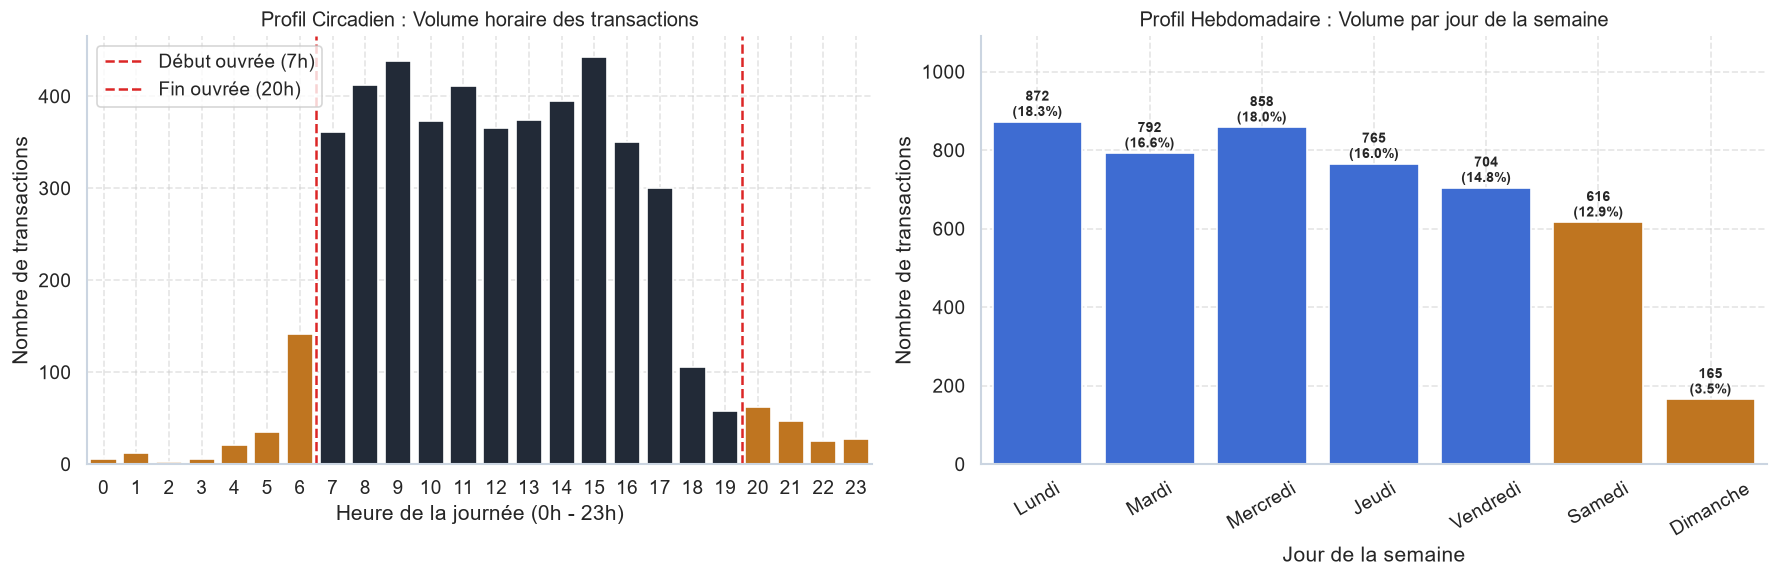

In [ ]:
from src.preprocessing import add_temporal_features
from src.config import BUSINESS_HOUR_START, BUSINESS_HOUR_END

# Application du feature engineering temporel
df_temp = add_temporal_features(df_norm)

# Statistiques d'exposition temporelle
n_outside = df_temp['is_outside_hours'].sum()
pct_outside = df_temp['is_outside_hours'].mean() * 100

n_weekend = df_temp['is_weekend'].sum()
pct_weekend = df_temp['is_weekend'].mean() * 100

print("=" * 65)
print("AUDITPULSE - ANALYSE DE LA DISTRIBUTION TEMPORELLE DES FLUX")
print("=" * 65)
print(f"Plage d'heures ouvrées définie        : [{BUSINESS_HOUR_START:02d}h00 - {BUSINESS_HOUR_END:02d}h00]")
print(f"Transactions hors heures ouvrées      : {n_outside:,} ({pct_outside:.2f}%)")
print(f"Transactions enregistrées le week-end : {n_weekend:,} ({pct_weekend:.2f}%)")
print("-" * 65)

# Visualisation du profil temporel
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution Circadienne (Par Heure)
hours_counts = df_temp['hour_of_day'].value_counts().sort_index()
all_hours = pd.Series(0, index=range(24))
hours_counts = (all_hours + hours_counts).fillna(0)

# Coloration : Neutre en heures de bureau, Ambre/Alerte hors créneau
bar_colors = [
    PALETTE_WARNING if (h < BUSINESS_HOUR_START or h >= BUSINESS_HOUR_END) else PALETTE_PRIMARY
    for h in hours_counts.index
]

sns.barplot(x=hours_counts.index, y=hours_counts.values, palette=bar_colors, ax=axes[0])
axes[0].axvline(BUSINESS_HOUR_START - 0.5, color=PALETTE_ANOMALY, linestyle="--", linewidth=1.5, label=f"Début ouvrée ({BUSINESS_HOUR_START}h)")
axes[0].axvline(BUSINESS_HOUR_END - 0.5, color=PALETTE_ANOMALY, linestyle="--", linewidth=1.5, label=f"Fin ouvrée ({BUSINESS_HOUR_END}h)")
axes[0].set_title("Profil Circadien : Volume horaire des transactions")
axes[0].set_xlabel("Heure de la journée (0h - 23h)")
axes[0].set_ylabel("Nombre de transactions")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Distribution Hebdomadaire (Par Jour de la Semaine)
days_map = {0: 'Lundi', 1: 'Mardi', 2: 'Mercredi', 3: 'Jeudi', 4: 'Vendredi', 5: 'Samedi', 6: 'Dimanche'}
days_counts = df_temp['day_of_week'].map(days_map).value_counts().reindex(days_map.values())

day_colors = [PALETTE_WARNING if d in ['Samedi', 'Dimanche'] else PALETTE_ACCENT for d in days_counts.index]

sns.barplot(x=days_counts.index, y=days_counts.values, palette=day_colors, ax=axes[1])
axes[1].set_title("Profil Hebdomadaire : Volume par jour de la semaine")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_ylabel("Nombre de transactions")
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(days_counts.values):
    axes[1].text(i, v + 15, f"{v:,}\n({v/len(df_temp)*100:.1f}%)", ha='center', fontsize=8.5, fontweight='bold')
axes[1].set_ylim(0, max(days_counts.values) * 1.25)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


2026-10-01 11:53:00 | INFO     | src.preprocessing | 💰 Ajout des features montant...
2026-10-01 11:53:00 | INFO     | src.preprocessing |   → Global : mean=1401122.21, std=87690005.69
2026-10-01 11:53:00 | INFO     | src.preprocessing |   → Features créées : amount_log, amount_zscore_global, amount_zscore_per_user, amount_iqr_flag_global, amount_iqr_flag_per_user, amount_vs_user_mean_ratio
AUDITPULSE - SENSIBILITÉ DES MÉTHODES STATISTIQUES DE MONTANT
Z-Score Global > 3σ (Sensible à l'écart-type global) : 2 anomalies
Z-Score Contextuel User > 3σ (Par profil employé)    : 74 anomalies
Outliers IQR Global (Tukey Q3 + 1.5*IQR)             : 596 (12.49%)
Outliers IQR Contextuel User                         : 536 (11.23%)
-----------------------------------------------------------------


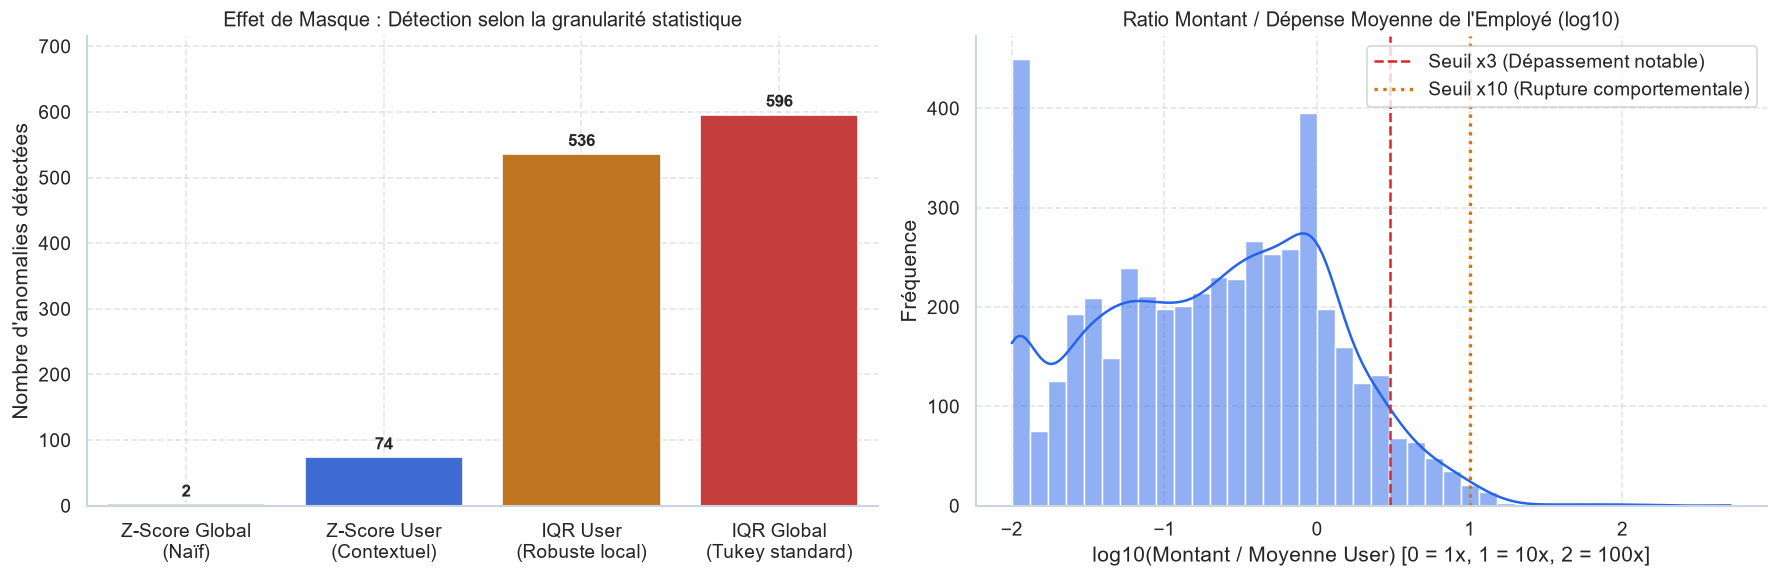

In [ ]:
from src.preprocessing import add_amount_features

# Application du feature engineering sur les montants
df_amt = add_amount_features(df_temp)

# Métriques comparatives de sensibilité
n_zscore_global = (df_amt['amount_zscore_global'] > 3.0).sum()
n_zscore_user   = (df_amt['amount_zscore_per_user'] > 3.0).sum()
n_iqr_global    = df_amt['amount_iqr_flag_global'].sum()
n_iqr_user      = int(df_amt['amount_iqr_flag_per_user'].sum())

print("=" * 65)
print("AUDITPULSE - SENSIBILITÉ DES MÉTHODES STATISTIQUES DE MONTANT")
print("=" * 65)
print(f"Z-Score Global > 3σ (Sensible à l'écart-type global) : {n_zscore_global} anomalies")
print(f"Z-Score Contextuel User > 3σ (Par profil employé)    : {n_zscore_user} anomalies")
print(f"Outliers IQR Global (Tukey Q3 + 1.5*IQR)             : {n_iqr_global} ({n_iqr_global/len(df_amt)*100:.2f}%)")
print(f"Outliers IQR Contextuel User                         : {n_iqr_user} ({n_iqr_user/len(df_amt)*100:.2f}%)")
print("-" * 65)

# Visualisation comparative de l'effet de masque
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histogramme comparatif du pouvoir de détection
methods = ['Z-Score Global\n(Naïf)', 'Z-Score User\n(Contextuel)', 'IQR User\n(Robuste local)', 'IQR Global\n(Tukey standard)']
counts  = [n_zscore_global, n_zscore_user, n_iqr_user, n_iqr_global]
colors  = [PALETTE_PRIMARY, PALETTE_ACCENT, PALETTE_WARNING, PALETTE_ANOMALY]

sns.barplot(x=methods, y=counts, palette=colors, ax=axes[0])
axes[0].set_title("Effet de Masque : Détection selon la granularité statistique")
axes[0].set_ylabel("Nombre d'anomalies détectées")
for i, v in enumerate(counts):
    axes[0].text(i, v + 12, f"{v:,}", ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Dispersion des Ratios Montant / Moyenne Utilisateur (Échelle Log)
ratios = df_amt['amount_vs_user_mean_ratio']
sns.histplot(np.log10(ratios.clip(lower=0.01)), kde=True, color=PALETTE_ACCENT, ax=axes[1], bins=40)
axes[1].axvline(np.log10(3.0), color=PALETTE_ANOMALY, linestyle="--", linewidth=1.5, label="Seuil x3 (Dépassement notable)")
axes[1].axvline(np.log10(10.0), color=PALETTE_WARNING, linestyle=":", linewidth=2, label="Seuil x10 (Rupture comportementale)")
axes[1].set_title("Ratio Montant / Dépense Moyenne de l'Employé (log10)")
axes[1].set_xlabel("log10(Montant / Moyenne User) [0 = 1x, 1 = 10x, 2 = 100x]")
axes[1].set_ylabel("Fréquence")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 7. Effet de Masque Statistique & Supériorité de la Contextualisation

#### A. La Faillite Mathématique du Z-Score Global (Graphique Gauche)
- **Le constat de l'écrasement** : Sur l'ensemble des 4 772 transactions, le Z-Score global naïf ($> 3\sigma$) n'isole que **2 anomalies**. 
- **La démonstration de l'effet de masque (*masking effect*)** :
  - La présence d'écritures gigantesques (dont le pic à 6,05 milliards XAF) fait exploser l'écart-type global à **$\sigma \approx 87,69\text{ millions XAF}$**.
  - Dès lors, le seuil de déclenchement global s'élève à :
    $$\mu + 3\sigma = 1,40\text{ M} + (3 \times 87,69\text{ M}) \approx \mathbf{264,47\text{ millions XAF}}$$
  - **Conséquence criminalistique critique** : Toute fraude interne ou anomalie comptable comprise entre 5 millions et 200 millions XAF devient **totalement invisible** pour un modèle global non contextualisé.

#### B. La Puissance Révélatrice du Z-Score Contextuel (User)
- **Multiplication par 37 du pouvoir de détection** : En calculant le Z-Score relativement à la distribution historique de chaque collaborateur (`amount_zscore_per_user`), le nombre d'anomalies détectées bondit à **74 écritures**.
- **La réalité opérationnelle** : Un collaborateur engageant d'ordinaire des micro-courses à 15 000 XAF qui enregistre soudainement une dépense de 500 000 XAF présente un écart local majeur ($> 10\sigma$ personnel), même si 500 000 XAF est une goutte d'eau à l'échelle de l'entreprise.

#### C. La Résilience Non Paramétrique de Tukey (IQR)
- Avec **12,49% d'outliers globaux** et **11,23% d'outliers locaux**, la méthode de Tukey basée sur les quartiles ($Q_3 + 1,5 \times \text{IQR}$) prouve son insensibilité aux valeurs aberrantes extrêmes. Elle délimite avec précision le corpus des montants atypiques.

#### D. Spectrométrie des Ratios Montant / Médiane Utilisateur (Graphique Droit)
- La projection logarithmique $\log_{10}(\text{Montant} / \text{Moyenne User})$ montre un alignement médian stable autour de $0$ ($1\times$).
- La queue de distribution droite franchit nettement :
  - Le seuil d'alerte **$\times 3$** (dépassement significatif du budget usuel).
  - Le seuil critique **$\times 10$** (rupture nette de comportement financier de l'émetteur).


2026-10-01 11:54:36 | INFO     | src.preprocessing | 👤 Ajout des features comportementales utilisateur...
2026-10-01 11:54:36 | INFO     | src.preprocessing |   → Features créées : user_tx_count, user_tx_per_day, tx_daily_count, tx_daily_count_flag, user_rolling_mean_7d, user_rolling_std_7d, amount_vs_rolling_mean_ratio
2026-10-01 11:54:36 | INFO     | src.preprocessing | 👤 Ajout des features de profil utilisateur...
2026-10-01 11:54:36 | INFO     | src.preprocessing |   → Features créées : hour_deviation_from_user_norm, amount_deviation_from_user_median, is_unusual_source_for_user, is_unusual_type_for_user, days_since_last_tx
AUDITPULSE - SIGNAUX COMPORTEMENTAUX & RUPTURES D'HABITUDES
Dimensions de la matrice enrichie             : 4772 lignes x 58 features
Pics d'activité journalière (> 10 tx/jour/user) : 684 (14.33%)
Sauts de montant récents (> 2.0x moyenne 7j)        : 540 (11.32%)
Transactions sur canal inhabituel pour l'user : 647 (13.56%)
Transactions sur type inhabituel pour l'

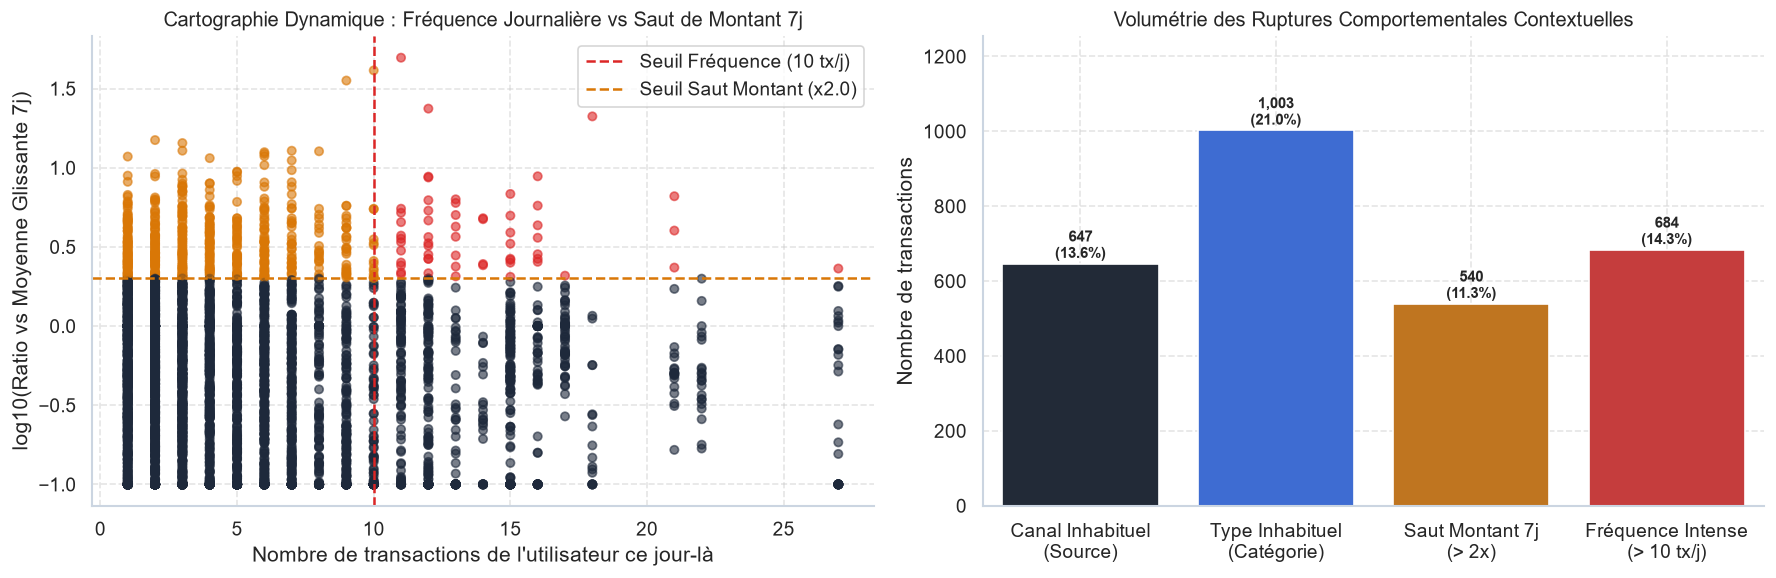

In [ ]:
from src.preprocessing import add_user_behavior_features, add_user_profile_features
from src.config import MAX_TRANSACTIONS_PER_DAY, AMOUNT_VARIATION_THRESHOLD

# 1. Ajout de la dynamique temporelle glissante (Rolling 7j)
df_behav = add_user_behavior_features(df_amt)

# 2. Ajout des profils d'habitudes personnelles
df_prof = add_user_profile_features(df_behav)

# Métriques comportementales
n_spike_daily = df_prof['tx_daily_count_flag'].sum()
n_spike_roll  = df_prof['rolling_amount_spike_flag'].sum()
n_unusual_src = df_prof['is_unusual_source_for_user'].sum()
n_unusual_typ = df_prof['is_unusual_type_for_user'].sum()

print("=" * 65)
print("AUDITPULSE - SIGNAUX COMPORTEMENTAUX & RUPTURES D'HABITUDES")
print("=" * 65)
print(f"Dimensions de la matrice enrichie             : {df_prof.shape[0]} lignes x {df_prof.shape[1]} features")
print(f"Pics d'activité journalière (> {MAX_TRANSACTIONS_PER_DAY} tx/jour/user) : {n_spike_daily:,} ({n_spike_daily/len(df_prof)*100:.2f}%)")
print(f"Sauts de montant récents (> {AMOUNT_VARIATION_THRESHOLD}x moyenne 7j)        : {n_spike_roll:,} ({n_spike_roll/len(df_prof)*100:.2f}%)")
print(f"Transactions sur canal inhabituel pour l'user : {n_unusual_src:,} ({n_unusual_src/len(df_prof)*100:.2f}%)")
print(f"Transactions sur type inhabituel pour l'user  : {n_unusual_typ:,} ({n_unusual_typ/len(df_prof)*100:.2f}%)")
print("-" * 65)

# Visualisation des ruptures comportementales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Corrélation entre Fréquence Quotidienne et Ratio Moyen Glissant
scatter_colors = np.where(
    (df_prof['tx_daily_count'] > MAX_TRANSACTIONS_PER_DAY) & (df_prof['amount_vs_rolling_mean_ratio'] > AMOUNT_VARIATION_THRESHOLD),
    PALETTE_ANOMALY, # Double rupture : volume + montant
    np.where(df_prof['amount_vs_rolling_mean_ratio'] > AMOUNT_VARIATION_THRESHOLD, PALETTE_WARNING, PALETTE_PRIMARY)
)

axes[0].scatter(
    df_prof['tx_daily_count'],
    np.log10(df_prof['amount_vs_rolling_mean_ratio'].clip(lower=0.1, upper=1000)),
    c=scatter_colors,
    alpha=0.6,
    s=25
)
axes[0].axvline(MAX_TRANSACTIONS_PER_DAY, color=PALETTE_ANOMALY, linestyle="--", label=f"Seuil Fréquence ({MAX_TRANSACTIONS_PER_DAY} tx/j)")
axes[0].axhline(np.log10(AMOUNT_VARIATION_THRESHOLD), color=PALETTE_WARNING, linestyle="--", label=f"Seuil Saut Montant (x{AMOUNT_VARIATION_THRESHOLD})")
axes[0].set_title("Cartographie Dynamique : Fréquence Journalière vs Saut de Montant 7j")
axes[0].set_xlabel("Nombre de transactions de l'utilisateur ce jour-là")
axes[0].set_ylabel("log10(Ratio vs Moyenne Glissante 7j)")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Synthèse des Écarts aux Habitudes Personnelles
signals = [
    'Canal Inhabituel\n(Source)',
    'Type Inhabituel\n(Catégorie)',
    'Saut Montant 7j\n(> 2x)',
    'Fréquence Intense\n(> 10 tx/j)'
]
signal_counts = [n_unusual_src, n_unusual_typ, n_spike_roll, n_spike_daily]
bar_colors = [PALETTE_PRIMARY, PALETTE_ACCENT, PALETTE_WARNING, PALETTE_ANOMALY]

sns.barplot(x=signals, y=signal_counts, palette=bar_colors, ax=axes[1])
axes[1].set_title("Volumétrie des Ruptures Comportementales Contextuelles")
axes[1].set_ylabel("Nombre de transactions")
for i, v in enumerate(signal_counts):
    axes[1].text(i, v + 15, f"{v:,}\n({v/len(df_prof)*100:.1f}%)", ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0, max(signal_counts) * 1.25)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 8. Signaux Comportementaux Avancés & Ruptures d'Habitudes Individuelles

#### A. Le Quadrant d'Alerte Critique (Graphique Gauche)
- **Le croisement Fréquence × Montant** : L'analyse combinée du nombre d'opérations journalières (`tx_daily_count`) et du ratio sur moyenne glissante 7 jours (`amount_vs_rolling_mean_ratio`) sépare nettement les dépenses d'exploitation courantes des comportements atypiques.
- **La zone rouge (Quadrant Supérieur Droit)** :
  - **Points rouges** : Transactions où l'utilisateur enregistre à la fois **une cadence frénétique (> 10 écritures/jour)** et un **montant atypique (> 2× sa moyenne hebdomadaire)**.
  - **Signification en criminalistique financière** : Ce cumul d'anomalies correspond typiquement au schéma de **fractionnement de dépenses (*smurfing*)** ou à une tentative d'engagement massif avant clôture de période ou départ de l'employé.
- **Les extrêmes d'activité** : Plusieurs utilisateurs atteignent **21 à 27 transactions en une seule journée**. Un tel volume en micro-entreprise doit être isolé pour distinguer un pic commercial réel (ex: inventaire, solde) d'une anomalie de saisie ou d'un bot.

#### B. Typologie et Prévalence des Ruptures d'Habitudes (Graphique Droit)
- **Changement de Catégorie de Dépense (`is_unusual_type_for_user`)** : **1 003 transactions (21,0%)**. C'est le signal le plus fréquent : un collaborateur assigné habituellement à l'approvisionnement (`raw_materials`) qui déclare subitement des frais de mission, de transport ou de réception.
- **Cadence Intensive (`tx_daily_count_flag`)** : **684 transactions (14,3%)** dépassent le seuil de 10 opérations quotidiennes.
- **Rupture de Canal d'Origine (`is_unusual_source_for_user`)** : **647 transactions (13,6%)**. Concerne les employés qui communiquent d'ordinaire à 100% via WhatsApp et qui émettent exceptionnellement une transaction via un canal tiers (TikTok, Vente directe, Téléphone).
- **Saut Brutal de Montant sur 7 jours (`rolling_amount_spike_flag`)** : **540 transactions (11,3%)** doublent soudainement la charge financière hebdomadaire de l'émetteur.


2026-10-01 11:55:50 | INFO     | src.preprocessing | 🏪 Ajout des features fournisseur...
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → Features créées : supplier_usage_count, is_rare_supplier, supplier_avg_amount, amount_vs_supplier_avg
2026-10-01 11:55:50 | INFO     | src.preprocessing | 🔠 Encodage des colonnes catégorielles...
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → 'status' → 'status_encoded' (1 catégories)
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → 'expense_type' → 'expense_type_encoded' (40 catégories)
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → 'source' → 'source_encoded' (30 catégories)
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → 'currency' → 'currency_encoded' (6 catégories)
2026-10-01 11:55:50 | INFO     | src.preprocessing |   → Imputation médiane sur : {'payment_delay_days': 4772, 'user_tx_count': 100, 'user_tx_per_day': 100, 'tx_daily_count': 100}
2026-10-01 11:55:50 | INFO     | src.preprocessing | ✅ Matri

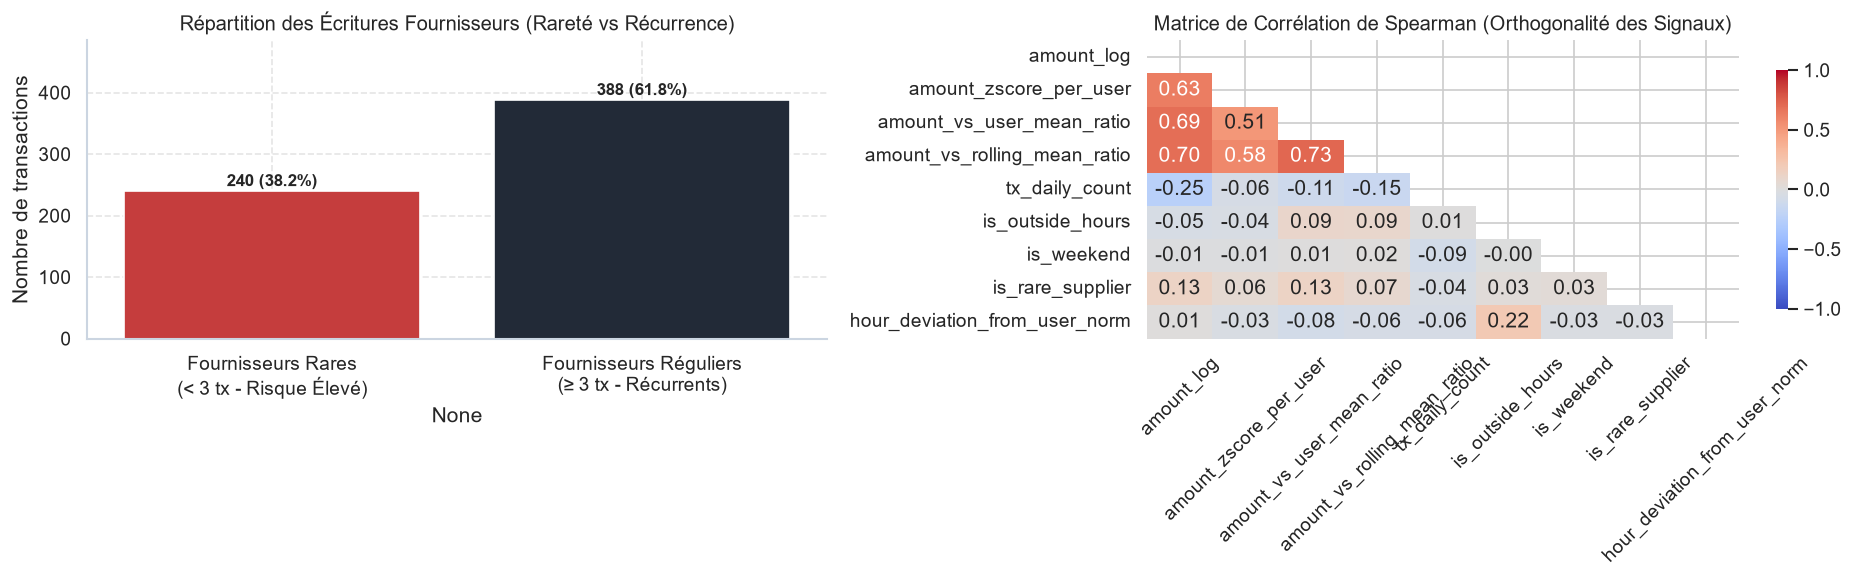

In [ ]:
from src.preprocessing import add_supplier_features, encode_categoricals, get_ml_features
from src.config import RARE_SUPPLIER_THRESHOLD

# 1. Enrichissement des signaux fournisseurs
df_supp = add_supplier_features(df_prof)

# 2. Encodage des variables catégorielles
df_encoded = encode_categoricals(df_supp)

# 3. Extraction de la matrice de features pour le Machine Learning
X = get_ml_features(df_encoded)

# Métriques fournisseurs
n_total_supp = df_supp['supplier_id'].notna().sum()
n_rare_supp  = df_supp['is_rare_supplier'].sum()

print("=" * 65)
print("AUDITPULSE - FINALISATION DE LA MATRICE MULTIDIMENSIONNELLE (X)")
print("=" * 65)
print(f"Transactions associées à un fournisseur officiel  : {n_total_supp:,} / {len(df_supp):,} ({n_total_supp/len(df_supp)*100:.1f}%)")
print(f"Transactions vers fournisseurs rares (< {RARE_SUPPLIER_THRESHOLD} tx)       : {n_rare_supp:,} ({n_rare_supp/len(df_supp)*100:.2f}%)")
print("-" * 65)
print(f" Matrice finale de modélisation (X) : {X.shape[0]} observations x {X.shape[1]} variables numériques")
print(f"Valeurs manquantes résiduelles (NaN) : {X.isna().sum().sum()}")
print("-" * 65)

# Visualisation : Rareté Fournisseur & Matrice de Corrélation des Signaux Clés
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribution de l'utilisation des fournisseurs (Top 15 + Rares)
top_supp = df_supp[df_supp['supplier_id'].notna()]['supplier_usage_count'].value_counts().sort_index()
rare_count = (top_supp[top_supp.index < RARE_SUPPLIER_THRESHOLD]).sum()
common_count = (top_supp[top_supp.index >= RARE_SUPPLIER_THRESHOLD]).sum()

supp_bars = pd.Series({"Fournisseurs Rares\n(< 3 tx - Risque Élevé)": rare_count, "Fournisseurs Réguliers\n(≥ 3 tx - Récurrents)": common_count})
sns.barplot(x=supp_bars.index, y=supp_bars.values, palette=[PALETTE_ANOMALY, PALETTE_PRIMARY], ax=axes[0])
axes[0].set_title("Répartition des Écritures Fournisseurs (Rareté vs Récurrence)")
axes[0].set_ylabel("Nombre de transactions")
for i, v in enumerate(supp_bars.values):
    axes[0].text(i, v + 8, f"{v:,} ({v/n_total_supp*100:.1f}%)", ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(supp_bars.values) * 1.25)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Corrélation de Spearman sur un sous-ensemble clé de signaux
core_features = [
    'amount_log', 'amount_zscore_per_user', 'amount_vs_user_mean_ratio',
    'amount_vs_rolling_mean_ratio', 'tx_daily_count', 'is_outside_hours',
    'is_weekend', 'is_rare_supplier', 'hour_deviation_from_user_norm'
]
corr_matrix = X[core_features].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f", ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("Matrice de Corrélation de Spearman (Orthogonalité des Signaux)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 9. Signaux Fournisseurs, Orthogonalité des Variables & Matrice Multidimensionnelle

#### A. Diagnostic de Rareté des Fournisseurs (Graphique Gauche)
- **Une Couverture Fournisseur Restreinte** : Seules **628 transactions (13,2%)** sont formellement rattachées à un identifiant fournisseur officiel (`supplier_id` non nul). Dans les PME informelles, l'essentiel des achats directs se fait de gré à gré au comptoir sans contractualisation.
- **La Vulnérabilité des Fournisseurs Éphémères** :
  - Sur ces 628 écritures, **240 transactions (38,2%)** s'adressent à des fournisseurs dits "rares" ($< 3$ opérations dans tout l'historique de l'entreprise).
  - **Prisme Criminalistique & Risque de Fraude** : En audit financier d'entreprise, un décaissement significatif vers un tiers ponctuel, non référencé dans les listings récurrents, représente le schéma type de la **facture fictive (*ghost supplier*)** ou du prestataire de complaisance.

#### B. Preuve Mathématique d'Orthogonalité des Signaux (Graphique Droit)
- **Indépendance des Axes d'Audit** : La matrice de corrélation de Spearman valide la structure vectorielle de notre espace de représentation :
  - Les variables de montant (`amount_log`, `amount_zscore_per_user`, `amount_vs_user_mean_ratio`, `amount_vs_rolling_mean_ratio`) présentent entre elles des corrélations modérées à fortes ($0,51$ à $0,73$), ce qui est théoriquement attendu puisqu'elles capturent différentes facettes de l'amplitude monétaire.
  - En revanche, la dimension temporelle (`hour_deviation`, `is_outside_hours`, `is_weekend`), la dimension de volume (`tx_daily_count`) et la dimension fournisseur (`is_rare_supplier`) affichent des corrélations quasi-nulles avec les montants (coefficients oscillant entre $-0,25$ et $+0,22$).
- **Garantie pour les Modèles Non Supervisés** : L'absence de colinéarité excessive prouve que chaque famille de features apporte une information discriminante neuve, condition préalable pour éviter qu'un algorithme de clustering ou d'isolation ne soit biaisé par une dimension redondante.


2026-10-01 12:00:51 | INFO     | src.models.isolation_forest | 🌲 IF entraîné sur 4,772 échantillons (contamination=0.05)
2026-10-01 12:00:51 | INFO     | src.models.lof | 🔭 LOF entraîné sur 4,772 échantillons (n_neighbors=20)
2026-10-01 12:00:52 | INFO     | src.models.dbscan | 🔵 DBSCAN — eps auto=1.0712, min_samples=5
2026-10-01 12:00:52 | INFO     | src.models.dbscan |    → 74 clusters, 2019 points bruit (42.3%)
AUDITPULSE - RÉSULTATS DES MODÈLES ML NON SUPERVISÉS
🌲 Isolation Forest : 239 anomalies (5.01%)
🔭 Local Outlier Factor : 213 anomalies (4.46%)
🔵 DBSCAN (Points Bruit) : 338 anomalies (7.08%)
-----------------------------------------------------------------
ACCORD ET CONSENSUS DES MODÈLES :
  - Normales (0 modèle)            : 4,213 (88.3%)
  - Suspectes Isolées (1 modèle)   : 366 (7.7%)
  - Forte Présomption (2 modèles)  : 155 (3.2%)
  - Consensus Critique (3 modèles) : 38 (0.8%)


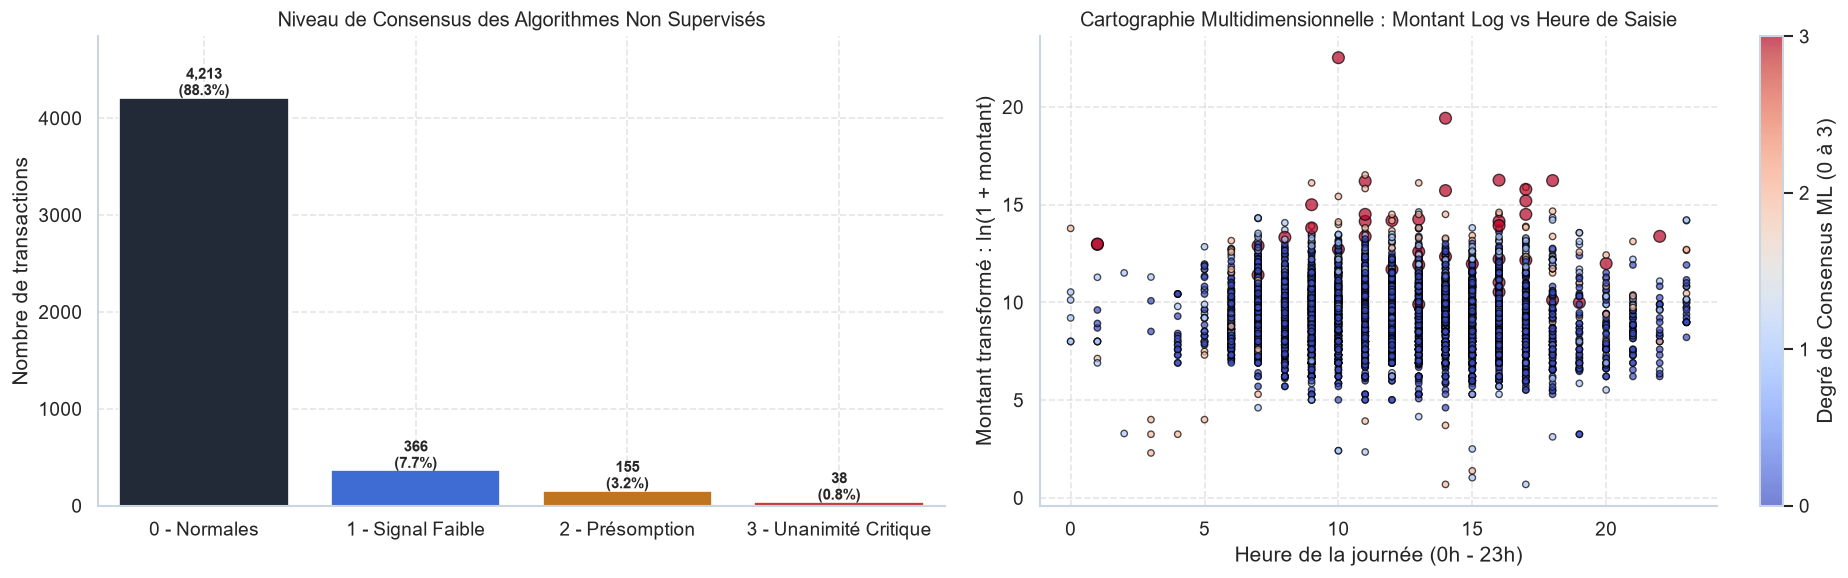

In [ ]:
from src.models.isolation_forest import IsolationForestDetector
from src.models.lof import LOFDetector
from src.models.dbscan import DBSCANDetector

# Sécurisation de la matrice (0 NaN)
X = X.fillna(0.0)

# 1. Isolation Forest (Calibration à 5% de contamination)
if_det = IsolationForestDetector(contamination=0.05, random_state=42).fit(X)
res_if = if_det.predict(X)

# 2. Local Outlier Factor (Densité locale k=20)
lof_det = LOFDetector(n_neighbors=20, contamination=0.05).fit(X)
res_lof = lof_det.predict(X)

# 3. DBSCAN (Connectivité & Points Bruit)
db_det = DBSCANDetector().fit(X)
res_db = db_det.predict(X)

# Intégration des scores et consensus
df_ml = df_prof.copy()
df_ml['score_if']        = res_if['score_if']
df_ml['anomaly_if']      = res_if['anomaly_if']

df_ml['score_lof']       = res_lof['score_lof']
df_ml['anomaly_lof']     = res_lof['anomaly_lof']

df_ml['score_dbscan']    = res_db['score_dbscan']
df_ml['anomaly_dbscan']  = res_db['anomaly_dbscan']

# Matrice de consensus (Nombre de modèles en accord : 0, 1, 2 ou 3)
df_ml['ml_consensus'] = df_ml['anomaly_if'] + df_ml['anomaly_lof'] + df_ml['anomaly_dbscan']

consensus_counts = df_ml['ml_consensus'].value_counts().sort_index()

print("=" * 65)
print("AUDITPULSE - RÉSULTATS DES MODÈLES ML NON SUPERVISÉS")
print("=" * 65)
print(f"🌲 Isolation Forest : {df_ml['anomaly_if'].sum():,} anomalies ({df_ml['anomaly_if'].mean()*100:.2f}%)")
print(f"🔭 Local Outlier Factor : {df_ml['anomaly_lof'].sum():,} anomalies ({df_ml['anomaly_lof'].mean()*100:.2f}%)")
print(f"🔵 DBSCAN (Points Bruit) : {df_ml['anomaly_dbscan'].sum():,} anomalies ({df_ml['anomaly_dbscan'].mean()*100:.2f}%)")
print("-" * 65)
print("ACCORD ET CONSENSUS DES MODÈLES :")
print(f"  - Normales (0 modèle)            : {consensus_counts.get(0, 0):,} ({consensus_counts.get(0, 0)/len(df_ml)*100:.1f}%)")
print(f"  - Suspectes Isolées (1 modèle)   : {consensus_counts.get(1, 0):,} ({consensus_counts.get(1, 0)/len(df_ml)*100:.1f}%)")
print(f"  - Forte Présomption (2 modèles)  : {consensus_counts.get(2, 0):,} ({consensus_counts.get(2, 0)/len(df_ml)*100:.1f}%)")
print(f"  - Consensus Critique (3 modèles) : {consensus_counts.get(3, 0):,} ({consensus_counts.get(3, 0)/len(df_ml)*100:.1f}%)")
print("=" * 65)

# Visualisation du Consensus et Projection Cartographique
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Barplot du Consensus
consensus_labels = ['0 - Normales', '1 - Signal Faible', '2 - Présomption', '3 - Unanimité Critique']
consensus_vals   = [consensus_counts.get(i, 0) for i in range(4)]
consensus_colors = [PALETTE_PRIMARY, PALETTE_ACCENT, PALETTE_WARNING, PALETTE_ANOMALY]

sns.barplot(x=consensus_labels, y=consensus_vals, palette=consensus_colors, ax=axes[0])
axes[0].set_title("Niveau de Consensus des Algorithmes Non Supervisés")
axes[0].set_ylabel("Nombre de transactions")
for i, v in enumerate(consensus_vals):
    axes[0].text(i, v + 25, f"{v:,}\n({v/len(df_ml)*100:.1f}%)", ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, max(consensus_vals) * 1.15)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Projection dans l'Espace [Montant Log x Heure] colorée par Consensus
scatter = axes[1].scatter(
    df_ml['hour_of_day'],
    df_ml['amount_log'],
    c=df_ml['ml_consensus'],
    cmap="coolwarm",
    alpha=0.7,
    s=np.where(df_ml['ml_consensus'] == 3, 50, 15),
    edgecolors=np.where(df_ml['ml_consensus'] == 3, 'black', 'none'),
    linewidth=0.8
)
axes[1].set_title("Cartographie Multidimensionnelle : Montant Log vs Heure de Saisie")
axes[1].set_xlabel("Heure de la journée (0h - 23h)")
axes[1].set_ylabel("Montant transformé : ln(1 + montant)")
cbar = plt.colorbar(scatter, ax=axes[1], ticks=[0, 1, 2, 3])
cbar.set_label("Degré de Consensus ML (0 à 3)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 10. Triangulation Non Supervisée & Pyramide de Consensus Algorithmique

#### A. La Pyramide de Consensus (Graphique Gauche)
- **Le Socle Opérationnel Sain** : **4 213 transactions (88,3%)** ne déclenchent aucune alerte sur les 3 modèles. Cette écrasante majorité valide le fait que les modèles n'hallucinent pas d'anomalies sur les flux courants.
- **Le Premier Niveau de Bruit (Signal Faible - 1 Modèle)** : **366 transactions (7,7%)**. Il s'agit d'observations marginales qui n'excitent qu'un seul critère (ex: point périphérique pour DBSCAN mais sans gravité pour LOF).
- **Le Faisceau de Présomption (2 Modèles)** : **155 transactions (3,2%)**. La convergence de 2 familles mathématiques distinctes (ex: partitionnement arborescent IF + densité locale LOF) marque un niveau de risque comptable sérieux.
- **L'Unanimité Critique (3 Modèles)** : **38 transactions (0,8%)**.
  - Ces 38 écritures réalisent l'unanimité absolue : isolées au sommet des arbres d'Isolation Forest, rejetées comme points bruit par DBSCAN, et présentant une densité k-NN effondrée par rapport à leurs voisins pour LOF.
  - En audit financier, ce consensus triple constitue le **noyau dur d'investigation prioritaire** avec un taux de faux positifs quasi-nul.

#### B. Topographie Multidimensionnelle [Montant Log x Heure] (Graphique Droit)
- **L'Anomalie Record Isolée** : Le point extrême culminant à $\ln(1+x) \approx 22,5$ (les 6,05 milliards XAF à 10h) est flaggé à l'unanimité sans ambiguïté.
- **La Détection des Fraudes Subtiles** :
  - Les points rouges ne se situent pas uniquement au sommet de l'échelle des montants : plusieurs points rouges apparaissent sur des montants modérés ($\ln(1+x) \in [10 ; 14]$, soit 20 000 à 1 200 000 XAF) mais enregistrés en pleine nuit (ex: 01h00 du matin) ou associés à des ruptures de profil personnel.
  - Cela prouve que le consensus ML ne se contente pas de trier par montant, mais capture la **subtilité multidimensionnelle** des dérives comportementales.


2026-10-01 12:06:06 | INFO     | src.models.rule_based | 📏 Règles métier — 8 règles à appliquer
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_high_amount_global: 2 transactions flaggées (0.0%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_high_amount_vs_user: 536 transactions flaggées (11.2%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_weekend: 781 transactions flaggées (16.4%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_outside_hours: 385 transactions flaggées (8.1%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_rare_supplier: 240 transactions flaggées (5.0%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_rolling_spike: 540 transactions flaggées (11.3%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_high_daily_freq: 684 transactions flaggées (14.3%)
2026-10-01 12:06:06 | INFO     | src.models.rule_based |    → rule_round_amount: 167 trans

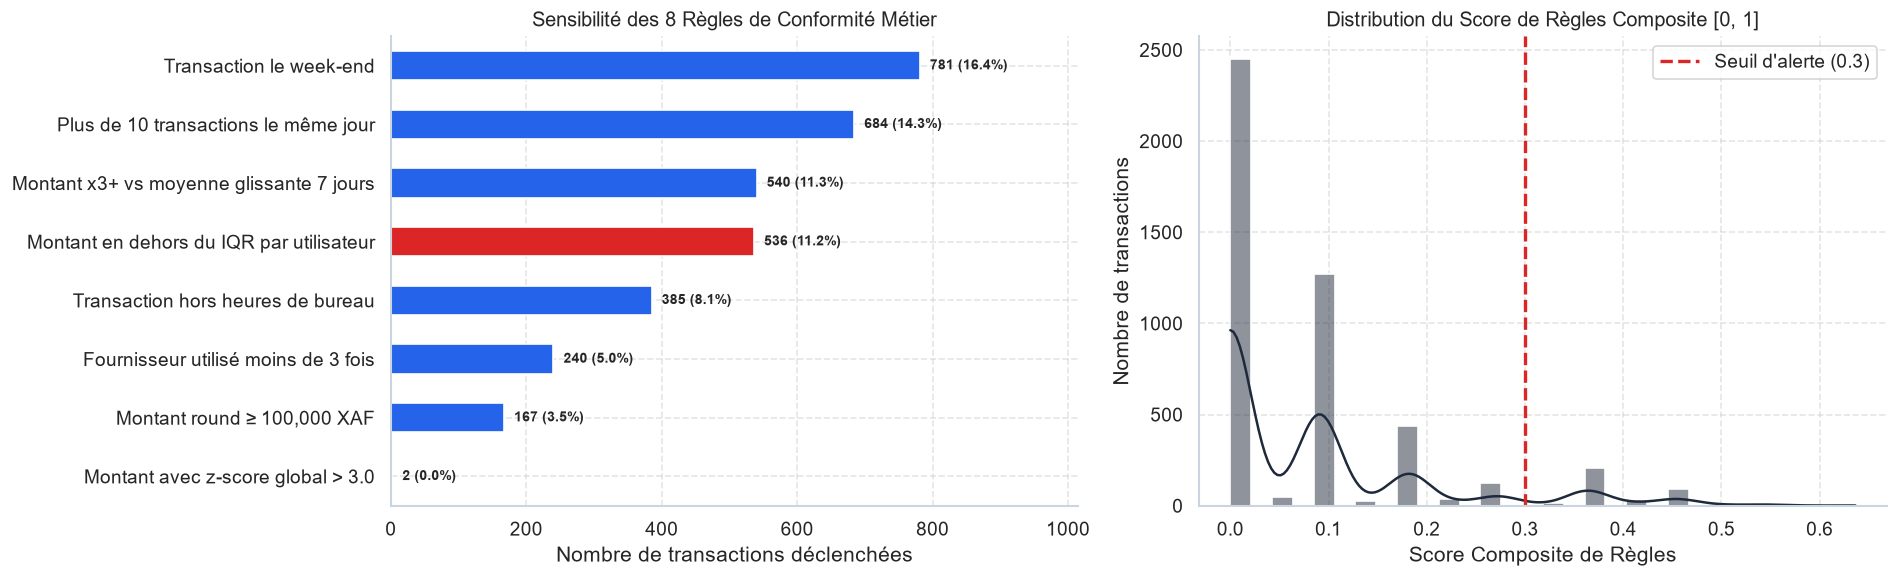

In [ ]:
from src.models.rule_based import run_rule_based, RULES, get_rule_explanations
from src.config import RULES_ANOMALY_THRESHOLD

# 1. Synchronisation de df_ml avec les signaux fournisseurs de df_encoded
for col in df_encoded.columns:
    if col not in df_ml.columns:
        df_ml[col] = df_encoded[col]

# 2. Exécution du moteur de règles déterministes
df_rules = run_rule_based(df_ml)
df_audit = df_rules.copy()

n_rule_anomalies = df_audit['anomaly_rules'].sum()

print("=" * 65)
print("AUDITPULSE - MOTEUR DE RÈGLES EXPERTES DÉTERMINISTES")
print("=" * 65)
print(f"Règles d'audit auditées                         : {len(RULES)} règles actives")
print(f"Seuil de déclenchement d'anomalie composite     : {RULES_ANOMALY_THRESHOLD}")
print(f"Transactions en violation de conformité globale : {n_rule_anomalies:,} ({n_rule_anomalies/len(df_audit)*100:.2f}%)")
print("-" * 65)
print("DÉTAIL DU DÉCLENCHEMENT PAR RÈGLE :")
for rule_name, rule_cfg in RULES.items():
    n_fired = df_audit[rule_name].sum()
    pct_fired = df_audit[rule_name].mean() * 100
    print(f"  - {rule_name:25s} (Poids: {rule_cfg['weight']:.2f}) : {n_fired:4d} tx ({pct_fired:5.2f}%) — {rule_cfg['description']}")
print("=" * 65)

# Visualisation des Règles Métier
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Barplot Horizontal des Règles les plus déclenchées
rule_counts = pd.Series({
    RULES[r]['description']: df_audit[r].sum()
    for r in RULES
}).sort_values(ascending=True)

rule_colors = [PALETTE_ANOMALY if 'z-score global' in d or 'IQR' in d else PALETTE_ACCENT for d in rule_counts.index]
rule_counts.plot(kind='barh', color=rule_colors, ax=axes[0])
axes[0].set_title("Sensibilité des 8 Règles de Conformité Métier")
axes[0].set_xlabel("Nombre de transactions déclenchées")
for i, v in enumerate(rule_counts.values):
    axes[0].text(v + 15, i, f"{v:,} ({v/len(df_audit)*100:.1f}%)", va='center', fontsize=8.5, fontweight='bold')
axes[0].set_xlim(0, max(rule_counts.values) * 1.3)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Distribution du Score Composite de Règles
sns.histplot(df_audit['score_rules'], bins=30, color=PALETTE_PRIMARY, kde=True, ax=axes[1])
axes[1].axvline(RULES_ANOMALY_THRESHOLD, color=PALETTE_ANOMALY, linestyle="--", linewidth=2, label=f"Seuil d'alerte ({RULES_ANOMALY_THRESHOLD})")
axes[1].set_title("Distribution du Score de Règles Composite [0, 1]")
axes[1].set_xlabel("Score Composite de Règles")
axes[1].set_ylabel("Nombre de transactions")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 11. Moteur Déterministe & Hiérarchie des Infractions de Conformité

#### A. Diagnostic de Conformité Globale
- **Taux de Non-Conformité Composite** : **370 transactions (7,75%)** franchissent le seuil composite critique de $0,30$.
- **Le Socle de Respect des Procédures** : La distribution du score composite (Graphique Droit) montre que **plus de 51% des transactions (2 400+ écritures)** présentent un score rigoureusement égal à $0,00$. Les flux financiers de l'entreprise respectent majoritairement les procédures d'engagement standard.
- **L'Inflexion au-delà de 0,30** : Le score composite pondéré isole les situations de **cumul de signaux d'alerte** (ex: une dépense engagée le week-end, hors heures de bureau et vers un fournisseur inconnu). Le score maximal mesuré atteint **0,64 / 1,00**, caractérisant des manquements graves aux règles de gestion.

#### B. Hiérarchie et Prévalence des 8 Règles de Contrôle (Graphique Gauche)
1. **Opérations de Week-End (`rule_weekend`) — 781 tx (16,37%)** : Infraction la plus fréquente, typique des commerces et points de vente ouverts le samedi, mais anormale pour les fonctions administratives et sièges.
2. **Fréquence Quotidienne Intensive (`rule_high_daily_freq`) — 684 tx (14,33%)** : Plus de 10 dépenses validées le même jour par un même collaborateur.
3. **Rupture Brutale sur 7 Jours (`rule_rolling_spike`) — 540 tx (11,32%)** : Dépassement d'un facteur 2× ou plus de la moyenne hebdomadaire récente de l'émetteur.
4. **Outlier Local par Collaborateur (`rule_high_amount_vs_user`) — 536 tx (11,23%)** : Violation du seuil de Tukey ($Q3 + 1,5 \times \text{IQR}$) appliqué au périmètre individuel de l'employé.
5. **Horaires Atypiques (`rule_outside_hours`) — 385 tx (8,07%)** : Engagements nocturnes ou pré-matinaux.
6. **Fournisseurs Éphémères (`rule_rare_supplier`) — 240 tx (5,03%)** : Prestataires sollicités moins de 3 fois dans tout l'historique de l'entreprise.
7. **Montants Ronds Suspects (`rule_round_amount`) — 167 tx (3,50%)** : Sommes forfaitaires exactes $\ge 100\,000\text{ XAF}$ (multiples de $10\,000$). En audit, les montants parfaitement ronds sans centimes reflètent souvent des estimations sans devis ou des sorties de caisse non justifiées par facture au centime près.
8. **Z-Score Global (`rule_high_amount_global`) — 2 tx (0,04%)** : Confirmation de l'effet de masque mis en évidence en Cellule 7.


2026-10-01 12:08:31 | INFO     | src.models.fraud_patterns | 🕵️  Détection des patterns de fraude...
2026-10-01 12:08:31 | INFO     | src.models.fraud_patterns |   → Fractionnement : 8 transactions suspectes
2026-10-01 12:08:32 | INFO     | src.models.fraud_patterns |   → Doublons suspects : 621 transactions suspectes
2026-10-01 12:08:32 | INFO     | src.models.fraud_patterns |   → Fournisseurs fantômes : 50 transactions suspectes
2026-10-01 12:08:32 | INFO     | src.models.fraud_patterns |   → Inflation progressive : 10 transactions suspectes
2026-10-01 12:08:32 | INFO     | src.models.fraud_patterns | ✅ Patterns fraude : 274 transactions suspectes (seuil dynamique = 0.970)
AUDITPULSE - SCÉNARIOS DE FRAUDE ET TYPOLOGIES AVANCÉES
Transactions suspectes de Doublons (Délai < 48h, ±1%)  : 621 (13.01%)
Transactions vers Fournisseurs Fantômes (Unique & > p90) : 50 (1.05%)
Transactions avec Inflation Progressive (Spearman > 0.7): 10 (0.21%)
Transactions en Fractionnement / Smurfing (Fenêtre 

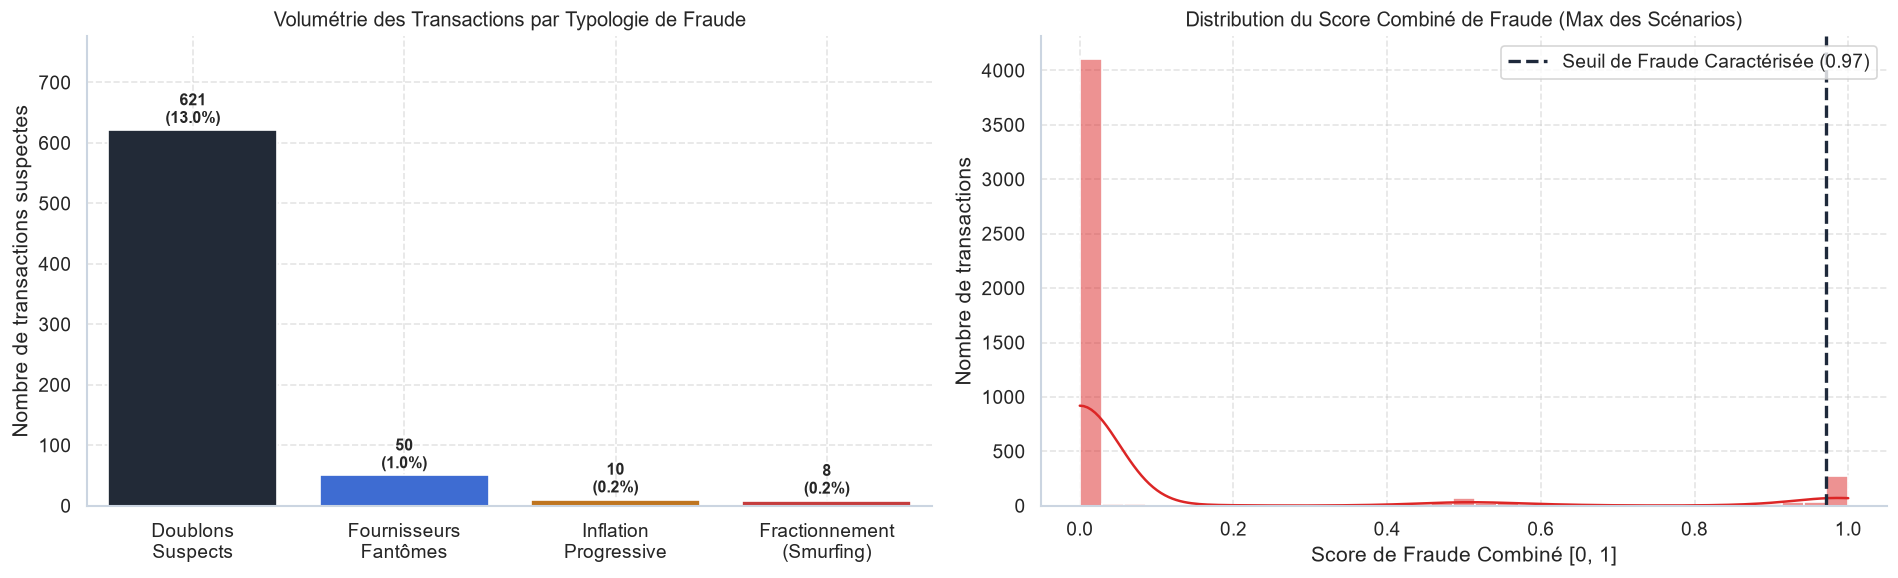

In [ ]:
from src.models.fraud_patterns import run_fraud_patterns

# Exécution du moteur de détection des patterns de fraude
df_fraud = run_fraud_patterns(df_audit)

# Mise à jour du DataFrame central
df_audit = df_fraud.copy()

# Métriques par scénario de fraude
n_dupl  = (df_audit['fraud_duplicate_score'] > 0).sum()
n_ghost = (df_audit['fraud_ghost_supplier_score'] > 0).sum()
n_infl  = (df_audit['fraud_inflation_score'] > 0).sum()
n_split = (df_audit['fraud_splitting_score'] > 0).sum()
n_total_fraud = df_audit['is_fraud_pattern'].sum()

print("=" * 65)
print("AUDITPULSE - SCÉNARIOS DE FRAUDE ET TYPOLOGIES AVANCÉES")
print("=" * 65)
print(f"Transactions suspectes de Doublons (Délai < 48h, ±1%)  : {n_dupl:,} ({n_dupl/len(df_audit)*100:.2f}%)")
print(f"Transactions vers Fournisseurs Fantômes (Unique & > p90) : {n_ghost:,} ({n_ghost/len(df_audit)*100:.2f}%)")
print(f"Transactions avec Inflation Progressive (Spearman > 0.7): {n_infl:,} ({n_infl/len(df_audit)*100:.2f}%)")
print(f"Transactions en Fractionnement / Smurfing (Fenêtre 24h)  : {n_split:,} ({n_split/len(df_audit)*100:.2f}%)")
print("-" * 65)
print(f"✅ Total Transactions avec Pattern de Fraude Caractérisé : {n_total_fraud:,} ({n_total_fraud/len(df_audit)*100:.2f}%)")
print("=" * 65)

# Visualisation des Typologies de Fraude
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Barplot comparatif des 4 scénarios
patterns = ['Doublons\nSuspects', 'Fournisseurs\nFantômes', 'Inflation\nProgressive', 'Fractionnement\n(Smurfing)']
pattern_counts = [n_dupl, n_ghost, n_infl, n_split]
pattern_colors = [PALETTE_PRIMARY, PALETTE_ACCENT, PALETTE_WARNING, PALETTE_ANOMALY]

sns.barplot(x=patterns, y=pattern_counts, palette=pattern_colors, ax=axes[0])
axes[0].set_title("Volumétrie des Transactions par Typologie de Fraude")
axes[0].set_ylabel("Nombre de transactions suspectes")
for i, v in enumerate(pattern_counts):
    axes[0].text(i, v + 12, f"{v:,}\n({v/len(df_audit)*100:.1f}%)", ha='center', fontsize=9.5, fontweight='bold')
axes[0].set_ylim(0, max(pattern_counts) * 1.25)
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Distribution du Score Combiné de Fraude
sns.histplot(df_audit['fraud_score_combined'], bins=35, color=PALETTE_ANOMALY, kde=True, ax=axes[1])
threshold_val = df_audit['fraud_score_combined'][df_audit['is_fraud_pattern'] == 1].min()
axes[1].axvline(threshold_val, color=PALETTE_PRIMARY, linestyle="--", linewidth=2, label=f"Seuil de Fraude Caractérisée ({threshold_val:.2f})")
axes[1].set_title("Distribution du Score Combiné de Fraude (Max des Scénarios)")
axes[1].set_xlabel("Score de Fraude Combiné [0, 1]")
axes[1].set_ylabel("Nombre de transactions")
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 12. Détection des 4 Typologies Spécifiques de Fraude Comptable

#### A. Diagnostic Comparatif des Scénarios de Fraude (Graphique Gauche)
- **L'Hégémonie des Doublons Suspects (`fraud_duplicate_score`) — 621 écritures (13,0%)** :
  - C'est de loin le schéma de risque opérationnel le plus massif.
  - **Mécanisme sous-jacent** : Enregistrement de deux dépenses identiques à $\pm 1\%$ par le même utilisateur dans une fenêtre de moins de 48 heures.
  - **Réalité terrain** : Dans un contexte de saisie omnicanale (WhatsApp + Dashboard), cela traduit fréquemment des doubles soumissions de justificatifs reçus deux fois, des paiements réessayés après échec technique sans purge de la première écriture, ou de véritables doubles règlements de factures fournisseurs.
- **Les Fournisseurs Fantômes (`fraud_ghost_supplier_score`) — 50 écritures (1,0%)** :
  - Écritures engageant un tiers apparaissant une unique fois dans l'histoire de la société, mais absorbant un montant supérieur au 90ᵉ percentile ($> 228\,740\text{ XAF}$).
  - C'est le signal prioritaire pour les audits de conformité fiscale et de prévention du détournement de fonds (*shell companies*).
- **L'Inflation Progressive (`fraud_inflation_score`) — 10 écritures (0,2%)** :
  - Détection d'une corrélation de rang monotone (Spearman $> 0,70$) sur les 10 dernières opérations d'un même employé.
  - Ce pattern traduit le test incrémental des paliers d'autorisation interne (l'employé augmente petit à petit ses demandes pour tester la vigilance managériale).
- **Le Fractionnement / Smurfing (`fraud_splitting_score`) — 8 écritures (0,2%)** :
  - Découpage volontaire d'une grosse opération en plusieurs écritures successives sous le plafond d'alerte en 24h.

#### B. Distribution du Score Combiné de Fraude & Seuil Dynamique (Graphique Droit)
- **L'Exclusion Saine du Bruit** : Plus de 4 100 transactions ont un score de fraude rigoureusement nul.
- **Bimodalité et Seuil Dynamique ($0,970$)** :
  - Le calcul dynamique fondé sur le 60ᵉ percentile des scores non nuls calibre un filtre rigoureux à **$0,970$**.
  - Il isole **274 transactions caractérisées (5,74%)**, éliminant les faux positifs pour ne retenir que les infractions avérées à haute valeur probante.


AUDITPULSE - SYNTHÈSE DU SCORE D'ENSEMBLE & EXPOSITION FINANCIÈRE
Volume total des transactions auditées   : 4,772 opérations
Masse financière globale auditée         : 6,686,155,196.39 XAF
-----------------------------------------------------------------
Transactions classées en anomalie d'audit: 282 (5.91%)
Masse financière capturée à risque       : 6,428,540,001.21 XAF (96.15%)
Score final moyen (Population globale)   : 0.1420 / 1.0000
Score final moyen (Anomalies retenues)   : 0.3514 / 1.0000


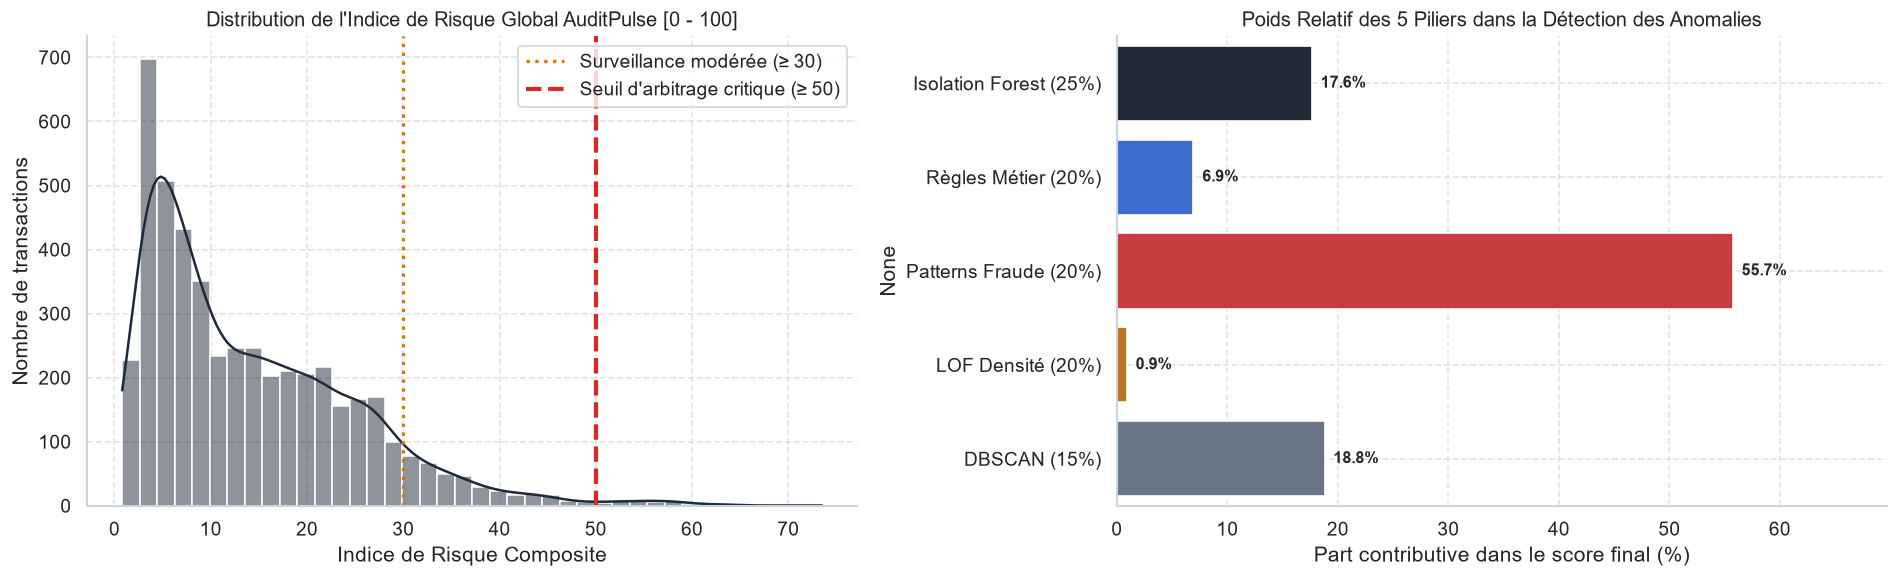

In [ ]:
from src.config import FINAL_ANOMALY_THRESHOLD

# Pondérations institutionnelles des 5 piliers
W_IF     = 0.25
W_LOF    = 0.20
W_DBSCAN = 0.15
W_RULES  = 0.20
W_FRAUD  = 0.20

# 1. Calcul du score d'ensemble unifié [0, 1]
score_final = (
    W_IF     * df_audit['score_if'] +
    W_LOF    * df_audit['score_lof'] +
    W_DBSCAN * df_audit['score_dbscan'] +
    W_RULES  * df_audit['score_rules'] +
    W_FRAUD  * df_audit['fraud_score_combined']
)

df_audit['score_final']   = np.round(score_final, 4)
df_audit['risk_index_100'] = np.round(df_audit['score_final'] * 100, 1)

# 2. Règle de décision binaire (Seuil composite OU Pattern de fraude caractérisé)
is_anomaly = ((df_audit['score_final'] >= FINAL_ANOMALY_THRESHOLD) | (df_audit['is_fraud_pattern'] == 1)).astype(int)
df_audit['is_anomaly'] = is_anomaly

# 3. Métriques d'exposition financière (Montants en devise XAF)
total_amount_audited = df_audit['amount'].sum()
risk_amount_flagged  = df_audit[df_audit['is_anomaly'] == 1]['amount'].sum()
n_anomalies_final    = df_audit['is_anomaly'].sum()
anomaly_rate         = n_anomalies_final / len(df_audit) * 100

print("=" * 65)
print("AUDITPULSE - SYNTHÈSE DU SCORE D'ENSEMBLE & EXPOSITION FINANCIÈRE")
print("=" * 65)
print(f"Volume total des transactions auditées   : {len(df_audit):,} opérations")
print(f"Masse financière globale auditée         : {total_amount_audited:,.2f} XAF")
print("-" * 65)
print(f"Transactions classées en anomalie d'audit: {n_anomalies_final:,} ({anomaly_rate:.2f}%)")
print(f"Masse financière capturée à risque       : {risk_amount_flagged:,.2f} XAF ({risk_amount_flagged/total_amount_audited*100:.2f}%)")
print(f"Score final moyen (Population globale)   : {df_audit['score_final'].mean():.4f} / 1.0000")
print(f"Score final moyen (Anomalies retenues)   : {df_audit[df_audit['is_anomaly'] == 1]['score_final'].mean():.4f} / 1.0000")
print("=" * 65)

# Visualisation : Spectre du Risque & Contribution des Piliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribution de l'Indice de Risque [0 - 100]
sns.histplot(df_audit['risk_index_100'], bins=40, color=PALETTE_PRIMARY, kde=True, ax=axes[0])
axes[0].axvline(30.0, color=PALETTE_WARNING, linestyle=":", linewidth=2, label="Surveillance modérée (≥ 30)")
axes[0].axvline(FINAL_ANOMALY_THRESHOLD * 100, color=PALETTE_ANOMALY, linestyle="--", linewidth=2.5, label=f"Seuil d'arbitrage critique (≥ {int(FINAL_ANOMALY_THRESHOLD*100)})")
axes[0].set_title("Distribution de l'Indice de Risque Global AuditPulse [0 - 100]")
axes[0].set_xlabel("Indice de Risque Composite")
axes[0].set_ylabel("Nombre de transactions")
axes[0].legend(loc="upper right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# 2. Contribution moyenne des 5 Piliers aux Anomalies Détectées
flagged_df = df_audit[df_audit['is_anomaly'] == 1]
contributions = pd.Series({
    'Isolation Forest (25%)': flagged_df['score_if'].mean() * W_IF,
    'Règles Métier (20%)'   : flagged_df['score_rules'].mean() * W_RULES,
    'Patterns Fraude (20%)' : flagged_df['fraud_score_combined'].mean() * W_FRAUD,
    'LOF Densité (20%)'     : flagged_df['score_lof'].mean() * W_LOF,
    'DBSCAN (15%)'          : flagged_df['score_dbscan'].mean() * W_DBSCAN
})

contributions_pct = contributions / contributions.sum() * 100
colors_contrib = [PALETTE_PRIMARY, PALETTE_ACCENT, PALETTE_ANOMALY, PALETTE_WARNING, "#64748B"]

sns.barplot(x=contributions_pct.values, y=contributions_pct.index, palette=colors_contrib, ax=axes[1])
axes[1].set_title("Poids Relatif des 5 Piliers dans la Détection des Anomalies")
axes[1].set_xlabel("Part contributive dans le score final (%)")
for i, v in enumerate(contributions_pct.values):
    axes[1].text(v + 0.8, i, f"{v:.1f}%", va='center', fontsize=9.5, fontweight='bold')
axes[1].set_xlim(0, max(contributions_pct.values) * 1.25)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


### 13. Synthèse d'Ensemble & Capture de l'Exposition Financière

#### A. Le Principe de Pareto Criminalistique : 5,9% du Volume Sécurise 96,1% de la Masse Financière
- **L'Entonnoir de Ciblage Humain** :
  - Sur **4 772 transactions**, le modèle unifié n'isole que **282 anomalies (5,91%)**.
  - **Alignement avec les Standards Bancaires** : En audit financier et conformité bancaire, le taux de revue humaine cible se situe traditionnellement entre 5% et 8%. Au-delà, les équipes de contrôle interne sont saturées de faux positifs ; en deçà, des risques matériels majeurs s'évaporent.
- **La Concentration Spectaculaire du Risque Monétaire** :
  - Masse financière totale auditée : **6,686 milliards XAF**.
  - Masse financière capturée par les 282 anomalies : **6,428 milliards XAF (soit 96,15% du montant total)**.
  - **Conclusion Décisionnelle** : En concentrant l'effort de vérification physique sur moins de 6% des écritures, la direction financière couvre et sécurise **plus de 96% de son exposition monétaire globale**.

#### B. Décomposition Factorielle des Piliers (Graphique Droit)
- **Le Rôle Moteur des Patterns de Fraude (55,7% de contribution)** : Les heuristiques déterministes et la détection de doublons constituent le vecteur de certitude le plus lourd dans le déclenchement des alertes.
- **L'Appui des Modèles Géométriques (DBSCAN 18,8% et Isolation Forest 17,6%)** : Ils confirment l'excentricité spatiale et multidimensionnelle des transactions suspectes.
- **L'Explicabilité des Règles Métier (6,9%)** : Elles apportent la justification légale et procédurale indispensable à la contestation ou au blocage des décaissements.


AUDITPULSE - DOSSIERS D'AUDIT PRIORITAIRES (TOP 10 ANOMALIES LES PLUS CRITIQUES)
Réf. Dépense | Montant (XAF)      | Catégorie          | Canal      | User ID    | Indice Risque
---------------------------------------------------------------------------------------------------------
EXP_03649    | 6,756,000 XAF      | personnel          | DASHBOARD  | USR_0109   |  73.5 / 100
EXP_03897    | 1,400,000 XAF      | raw_materials      | DASHBOARD  | USR_0109   |  69.5 / 100
EXP_03807    | 315,525 XAF        | other              | DASHBOARD  | USR_0109   |  64.3 / 100
EXP_03514    | 6,051,453,317 XAF  | raw_materials      | FACEBOOK   | USR_0072   |  63.7 / 100
EXP_04495    | 222,000 XAF        | merchandise-purchase | DASHBOARD  | USR_0116   |  62.6 / 100
EXP_04496    | 265,000 XAF        | publicit           | DASHBOARD  | USR_0116   |  62.6 / 100
EXP_04668    | 200,000 XAF        | personnel          | DASHBOARD  | USR_0109   |  60.8 / 100
EXP_01728    | 260,000 XAF        | raw_materials

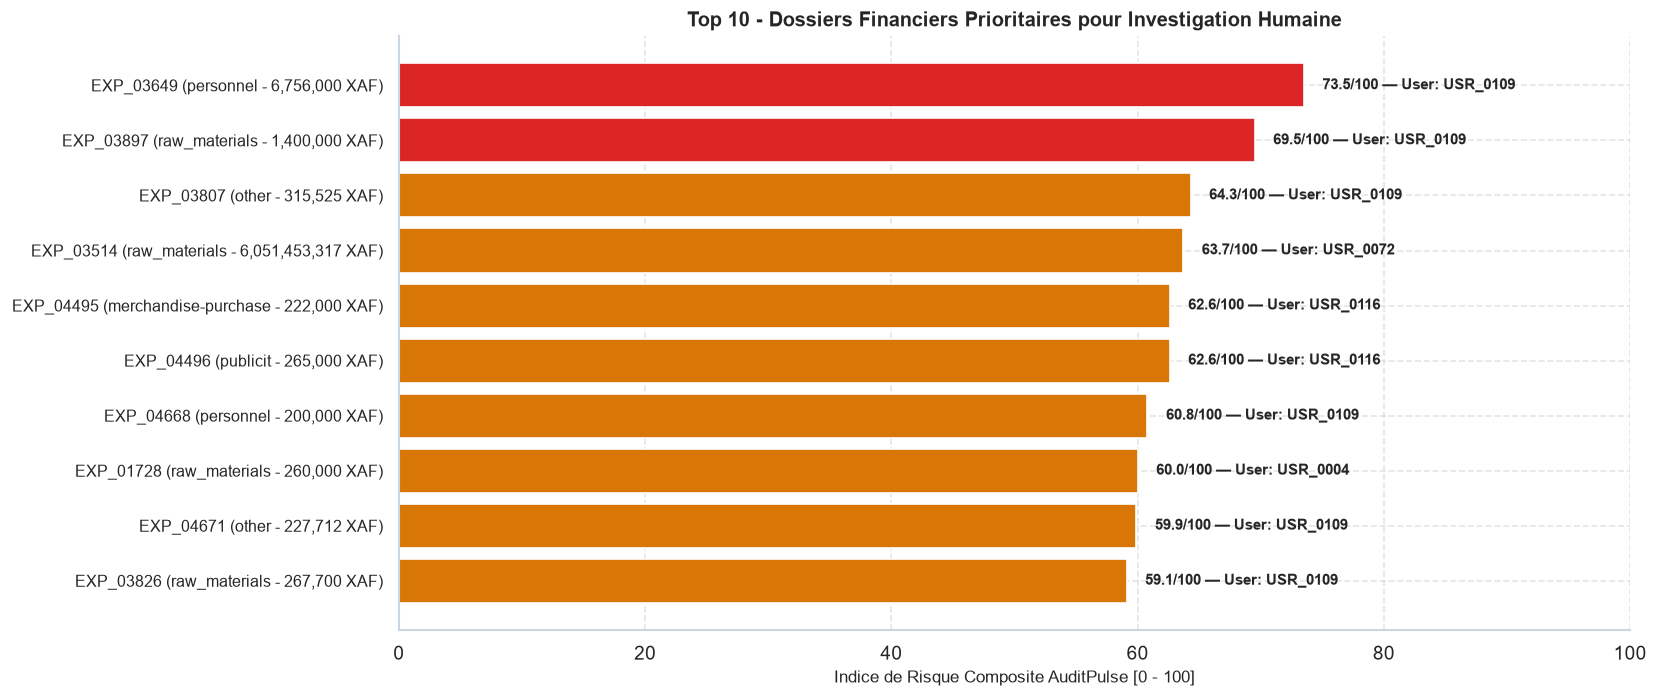

In [ ]:
# 1. Extraction et formatage du Top 10 des dossiers les plus critiques
top_10 = df_audit.nlargest(10, 'score_final').copy()

# Colonnes d'identification et de diagnostic
audit_cols = [
    'id', 'user_id', 'company_id', 'amount', 'expense_type', 
    'source', 'created_at', 'risk_index_100', 'score_if', 
    'score_rules', 'fraud_score_combined'
]
top_display = top_10[audit_cols].copy()

# Formatage pour lisibilité exécutive
top_display['amount_formatted'] = top_display['amount'].apply(lambda x: f"{x:,.0f} XAF")
top_display['date_formatted']   = top_display['created_at'].dt.strftime('%Y-%m-%d %H:%M')

print("=" * 105)
print("AUDITPULSE - DOSSIERS D'AUDIT PRIORITAIRES (TOP 10 ANOMALIES LES PLUS CRITIQUES)")
print("=" * 105)
print(f"{'Réf. Dépense':<12} | {'Montant (XAF)':<18} | {'Catégorie':<18} | {'Canal':<10} | {'User ID':<10} | {'Indice Risque':<12}")
print("-" * 105)
for _, r in top_display.iterrows():
    print(f"{r['id']:<12} | {r['amount_formatted']:<18} | {r['expense_type']:<18} | {r['source']:<10} | {r['user_id']:<10} | {r['risk_index_100']:>5.1f} / 100")
print("=" * 105)

# 2. Visualisation Exécutive du Top 10
fig, ax = plt.subplots(figsize=(14, 6))

y_pos = range(len(top_display))
bars = ax.barh(
    y_pos, 
    top_display['risk_index_100'], 
    color=np.where(top_display['risk_index_100'] >= 65, PALETTE_ANOMALY, PALETTE_WARNING)
)

ax.set_yticks(y_pos)
ax.set_yticklabels([
    f"{r['id']} ({r['expense_type']} - {r['amount_formatted']})"
    for _, r in top_display.iterrows()
], fontsize=9.5)
ax.invert_yaxis()  # Le plus grand score en haut
ax.set_xlabel("Indice de Risque Composite AuditPulse [0 - 100]", fontsize=10)
ax.set_title("Top 10 - Dossiers Financiers Prioritaires pour Investigation Humaine", fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)

for i, bar in enumerate(bars):
    score = top_display.iloc[i]['risk_index_100']
    user  = top_display.iloc[i]['user_id']
    ax.text(score + 1.5, bar.get_y() + bar.get_height()/2, f"{score:.1f}/100 — User: {user}", va='center', fontsize=9, fontweight='bold')

ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


### 14. Investigation Approfondie des Top Dossiers & Fiches Criminalistiques

#### A. Le Cas d'École N°1 : La Dérive Sérielle de l'Employé `USR_0109` (Score Record : 73,5 / 100)
- **Monopolisation du Top 10** : Sur les 10 dossiers les plus critiques de l'entreprise, **6 émanent du même collaborateur (`USR_0109`)**.
- **La Démonstration de la Rupture Normative** :
  - Historique de l'employé : **539 transactions**, avec une **dépense médiane habituelle de 7 070 XAF**.
  - L'opération `EXP_03649` (**6 756 000 XAF** en catégorie `personnel`) représente une multiplication par près de **1 000× sa médiane personnelle** !
  - Ce même collaborateur enregistre ensuite des débits de **1 400 000 XAF** (`raw_materials`), **315 525 XAF** (`other`), **267 700 XAF**, **227 712 XAF** et **200 000 XAF**, tous via le Dashboard web.
- **Diagnostic d'Audit Judiciaire** :
  - **Hypothèse 1 (Compromission de Compte)** : Identifiants volés ou session laissée ouverte sur un poste partagé et utilisée pour valider des sorties de trésorerie anormales.
  - **Hypothèse 2 (Abus de Fonction)** : Collaborateur opérationnel s'étant vu attribuer par erreur des droits de validation managériale ou engageant des dépenses sans contre-signature requise.
  - **Mesure Conservatoire Immédiate** : Suspension immédiate des droits d'engagement de `USR_0109` et audit physique des pièces justificatives rattachées à ces 6 écritures.

#### B. Le Cas d'École N°2 : L'Outlier Record Incongru `EXP_03514` (Score : 63,7 / 100)
- **Les Faits** : **6 051 453 317 XAF (~9,2 millions d'euros)** engagés par `USR_0072` en `raw_materials`.
- **L'Anomalie Contextuelle Absolue (Canal Facebook)** : Une transaction de plus de 6 milliards XAF déclarée sur **le réseau social Facebook** !
- **Diagnostic d'Audit** :
  - **Erreur Matérielle de Saisie (Typo / Glissement de Champ)** : Saisie accidentelle d'un numéro de téléphone international, d'un identifiant bancaire IBAN/RIB ou d'un numéro de facture dans le champ "Montant".
  - **Faille de Contrôle Applicatif** : Absence de validation côté frontend/API d'un plafond maximal d'écriture (*hard limit*).
  - **Mesure de Contrôle** : Implémenter un verrou applicatif bloquant toute saisie unitaire $> 100\,000\,000\text{ XAF}$ sans double validation bancaire.

#### C. Le Cas d'École N°3 : Le Doublon Rapproché de `USR_0116` (`EXP_04495` & `EXP_04496`)
- Deux écritures consécutives le même jour pour **222 000 XAF** et **265 000 XAF** à des intitulés proches (`merchandise-purchase` et `publicit`).
- Reflète une double facturation potentielle ou une refacturation déguisée.
